# 1- Variable Construction

## 1.1 Y- China Strategy & X- CEO Sentiment

In [1]:
import pandas as pd
import re

df = pd.read_excel("extracted_edgar_earnings_china_sentences.xlsx")

df.columns = df.columns.str.strip().str.lower()

In [2]:
# 2. Define action keywords (distinguish Exit vs Double-down)

# Exit / De-risk keywords (sale, shutdown, relocation, reduction)
exit_keywords = [
    r'\bsell\b', r'\bsold\b', r'\bsale\b', r'\bdivest', r'\bdispos',  # sale / divestment
    r'\bexit\b', r'\bexited\b', r'\bexiting\b',                        # exit
    r'\bshut\s*down', r'\bclose[d]?\b', r'\bclosure\b',               # shutdown / closure
    r'\bwind\s*down', r'\bterminat',                                   # termination
    r'\bdiscontinue', r'\bcease[d]?\b',                                # discontinuation
    r'\brestructur',                                                   # restructuring
    r'\brelocat', r'\btransfer\s*(production|manufacturing|operations)', # relocation / transfer
    r'\bmove[d]?\s*(production|manufacturing|out)',                    # move out
    r'\breduce[d]?\s*(footprint|exposure|operations|presence)',        # reduction
    r'\bwithdraw', r'\bpull\s*out',                                    # withdrawal
]

# Double-down keywords (expansion, investment, new facilities, entry)
dd_keywords = [
    r'\bexpand', r'\bexpansion\b',                                     # expansion
    r'\binvest(?!igat)', r'\binvestment\b',                            # investment (exclude investigate)
    r'\bbuild\b', r'\bbuilt\b', r'\bconstruct',                        # construction
    r'\bopen(?:ed|ing)?\s*(a|new|additional)?\s*(facility|plant|factory|office|center)', # opening facilities
    r'\bnew\s*(facility|plant|factory|manufacturing|R&D|center)',      # new facility
    r'\bramp', r'\bcapacity\s*(increase|expansion|addition)',          # capacity expansion
    r'\bestablish', r'\blaunch',                                       # establish / launch
    r'\bform(?:ed)?\s*(a\s*)?(joint\s*venture|JV|partnership)',        # form a JV / partnership
    r'\bjoint\s*venture', r'\bJV\b',                                   # joint venture
    r'\bacquir', r'\bacquisition\b',                                   # acquisition
    r'\bhir(?:e|ed|ing)\b.*china', r'\bheadcount\s*increase',          # hiring expansion
    r'\blocalization\b', r'\blocalize\b',                              # localization
    r'\bcommit(?:ted|ment)?\b.*(?:china|expansion)',                   # commitment to China / expansion
    r'\bdouble\s*down',                                                # double down
]

# Exclusion patterns (avoid misclassifying hypothetical statements such as
# "may sell" or "risk of closure" as realized actions)
hypothetical_patterns = [
    r'\bmay\s+(sell|close|exit|divest|discontinue)',
    r'\bcould\s+(sell|close|exit|divest|discontinue)',
    r'\bmight\s+(sell|close|exit|divest|discontinue)',
    r'\brisk\s+of\s+(closure|exit|sale)',
    r'\bif\s+we\s+(sell|close|exit)',
    r'\bplan\s+to\s+(sell|close|exit)',
]


In [3]:
# 3. Functions: identify whether a sentence contains an action

def has_exit_action(sentence):
    """Detect whether the sentence contains an exit / de-risk action."""
    s = str(sentence).lower()
    # First exclude hypothetical statements
    for hypo in hypothetical_patterns:
        if re.search(hypo, s):
            return False
    # Then check exit keywords
    for kw in exit_keywords:
        if re.search(kw, s):
            return True
    return False

def has_dd_action(sentence):
    """Detect whether the sentence contains a double-down / expansion action."""
    s = str(sentence).lower()
    for kw in dd_keywords:
        if re.search(kw, s):
            return True
    return False

def is_action_sentence(sentence):
    """Determine whether the sentence is an action sentence (action vs non-action)."""
    return has_exit_action(sentence) or has_dd_action(sentence)


In [4]:
# 4. Label each sentence
df['exit_action'] = df['sentence'].apply(has_exit_action).astype(int)
df['dd_action'] = df['sentence'].apply(has_dd_action).astype(int)
df['is_action'] = df['sentence'].apply(is_action_sentence).astype(int)

# 5. Aggregate to a firm-year panel: Strategy variable
strategy_df = df.groupby(['ticker', 'year']).agg(
    exit_count=('exit_action', 'sum'),             # number of exit-action sentences
    dd_count=('dd_action', 'sum'),                 # number of double-down sentences
    total_china_sentences=('sentence', 'count'),   # total number of China-related sentences
).reset_index()

# Construct the three-category Strategy Y
def get_strategy_y(row):
    """
    Y = -1: Exit/De-risk (exit actions only, no double-down)
    Y = +1: Double-down (double-down actions only, no exit)
    Y =  0: Maintain (no action, or both types present = restructure year)
    NaN: no China-related sentence for this firm-year
    """
    if pd.isna(row['exit_count']) or pd.isna(row['dd_count']):
        return np.nan

    has_exit = row['exit_count'] > 0
    has_dd = row['dd_count'] > 0

    if has_exit and not has_dd:
        return -1
    elif has_dd and not has_exit:
        return 1
    else:
        return 0

strategy_df['strategy_Y'] = strategy_df.apply(get_strategy_y, axis=1)

# mark "mixed years" for robustness analysis
strategy_df['mixed_year'] = ((strategy_df['exit_count'] > 0) & (strategy_df['dd_count'] > 0)).astype(int)

In [5]:
# 6. Aggregate to a firm-year panel: Sentiment variable (using non-action sentences only)
# Keep only non-action sentences to calculate sentiment
non_action_df = df[df['is_action'] == 0].copy()

sentiment_df = non_action_df.groupby(['ticker', 'year']).agg(
    sentiment_mean=('score', lambda x: x.map({'positive': 1, 'neutral': 0, 'negative': -1}).mean()
                    if x.dtype == 'object' else x.mean()),
    sentiment_positive_pct=('score', lambda x: (x == 'positive').mean() if x.dtype == 'object' else None),
    sentiment_negative_pct=('score', lambda x: (x == 'negative').mean() if x.dtype == 'object' else None),
    non_action_sentence_count=('sentence', 'count'),
).reset_index()

# 7. Merge Strategy + Sentiment into the final panel
panel_df = strategy_df.merge(sentiment_df, on=['ticker', 'year'], how='left')

In [6]:
# 8. Output results
# Preview sample rows
print("=== Strategy Summary ===")
print(panel_df[['ticker', 'year', 'strategy_Y', 'exit_count', 'dd_count', 'mixed_year']].head(20))

print("\n=== Strategy Distribution ===")
print(panel_df['strategy_Y'].value_counts())

print("\n=== Mixed Years (both exit and double-down) ===")
print(panel_df[panel_df['mixed_year'] == 1][['ticker', 'year', 'exit_count', 'dd_count']])

# 9. View examples of sentences labeled as action for manual validation
action_sentences = df[df['is_action'] == 1][['ticker', 'year', 'sentence', 'exit_action', 'dd_action']]

=== Strategy Summary ===
   ticker  year  strategy_Y  exit_count  dd_count  mixed_year
0    AAPL  2014           1           0         1           0
1    AAPL  2015           1           0         1           0
2    AAPL  2016           0           0         0           0
3    AAPL  2017           0           0         0           0
4    AAPL  2018           0           0         0           0
5    AAPL  2019           0           0         0           0
6    AAPL  2020           0           0         0           0
7    AAPL  2021           0           0         0           0
8    AAPL  2022           0           0         0           0
9    AAPL  2023           0           0         0           0
10   AAPL  2024           0           0         0           0
11   AAPL  2025           0           0         0           0
12    ABT  2014           1           0         2           0
13    ABT  2015           1           0         8           0
14    ABT  2016           1           0      

In [7]:
# Check overlap between strategy and sentiment

print("=== Strategy-Sentiment Coverage Check ===")

# have sentiment？
panel_df['has_sentiment'] = panel_df['sentiment_mean'].notna().astype(int)

# have strategy？
panel_df['has_strategy'] = panel_df['strategy_Y'].notna().astype(int)

# 1. summary
total_obs = len(panel_df)
both_count = ((panel_df['has_strategy'] == 1) & (panel_df['has_sentiment'] == 1)).sum()
strategy_only_count = ((panel_df['has_strategy'] == 1) & (panel_df['has_sentiment'] == 0)).sum()

print(f"Total firm-year observations in panel: {total_obs}")
print(f"Firm-years with both strategy and sentiment: {both_count}")
print(f"Firm-years with strategy only (missing sentiment): {strategy_only_count}")
print(f"Share with both strategy and sentiment: {both_count / total_obs:.2%}")

# 2. which observation do not have sentiment
print("\n=== Firm-years with strategy but missing sentiment ===")
missing_sentiment = panel_df[panel_df['has_sentiment'] == 0][
    ['ticker', 'year', 'strategy_Y', 'exit_count', 'dd_count', 'total_china_sentences']
].sort_values(['ticker', 'year'])

print(missing_sentiment.to_string(index=False))

# 3. group by Company
print("\n=== Coverage by firm ===")
coverage_by_firm = panel_df.groupby('ticker').agg(
    total_firm_years=('year', 'count'),
    with_sentiment=('has_sentiment', 'sum')
).reset_index()

coverage_by_firm['with_both_share'] = coverage_by_firm['with_sentiment'] / coverage_by_firm['total_firm_years']
print(coverage_by_firm.to_string(index=False))

=== Strategy-Sentiment Coverage Check ===
Total firm-year observations in panel: 548
Firm-years with both strategy and sentiment: 542
Firm-years with strategy only (missing sentiment): 6
Share with both strategy and sentiment: 98.91%

=== Firm-years with strategy but missing sentiment ===
ticker  year  strategy_Y  exit_count  dd_count  total_china_sentences
  CSCO  2022          -1           1         0                      1
   JNJ  2020          -1           1         0                      1
   MRK  2017           0           1         1                      2
   PFE  2014           1           0         1                      1
   TDY  2019          -1           1         0                      1
   ZTS  2014           1           0         1                      1

=== Coverage by firm ===
ticker  total_firm_years  with_sentiment  with_both_share
  AAPL                12              12         1.000000
   ABT                12              12         1.000000
  AMAT              

In [8]:
# Drop firms with fewer than 8 firm-year observations

# Count firm-year observations for each ticker
firm_counts = panel_df.groupby('ticker')['year'].count().reset_index()
firm_counts.columns = ['ticker', 'total_firm_years']

# Keep only firms with at least 8 observations
keep_tickers = firm_counts.loc[firm_counts['total_firm_years'] >= 8, 'ticker']

# Filter panel
panel_df_filtered = panel_df[panel_df['ticker'].isin(keep_tickers)].copy()


# Check results
dropped_tickers = firm_counts.loc[firm_counts['total_firm_years'] < 8, 'ticker'].tolist()

print("=== Firms dropped (< 8 firm-year observations) ===")
print(dropped_tickers)

print("\n=== Filtered panel summary ===")
print(f"Original number of rows: {len(panel_df)}")
print(f"Filtered number of rows: {len(panel_df_filtered)}")
print(f"Original number of firms: {panel_df['ticker'].nunique()}")
print(f"Filtered number of firms: {panel_df_filtered['ticker'].nunique()}")

=== Firms dropped (< 8 firm-year observations) ===
['AMGN', 'ANET', 'CSCO', 'IBM', 'MSFT', 'TDY', 'VTRS']

=== Filtered panel summary ===
Original number of rows: 548
Filtered number of rows: 509
Original number of firms: 52
Filtered number of firms: 45


In [9]:
panel_df_filtered.head()

,ticker,year,exit_count,dd_count,total_china_sentences,strategy_Y,mixed_year,sentiment_mean,sentiment_positive_pct,sentiment_negative_pct,non_action_sentence_count,has_sentiment,has_strategy
0,AAPL,2014,0,1,12,1,0,0.181818,0.454545,0.272727,11.0,1,1
1,AAPL,2015,0,1,11,1,0,0.300000,0.500000,0.200000,10.0,1,1
2,AAPL,2016,0,0,7,0,0,0.142857,0.285714,0.142857,7.0,1,1
3,AAPL,2017,0,0,8,0,0,-0.250000,0.125000,0.375000,8.0,1,1
4,AAPL,2018,0,0,9,0,0,0.111111,0.333333,0.222222,9.0,1,1


### Missing Value

In [10]:
import pandas as pd
from itertools import product

panel_df = panel_df_filtered.copy()

# 1. Construct a full firm-year grid
all_tickers = sorted(panel_df['ticker'].unique())
all_years = list(range(2014, 2026))   # 2014-2025

full_grid = pd.DataFrame(
    list(product(all_tickers, all_years)),
    columns=['ticker', 'year']
)

# Merge original panel into the full grid
panel_df = full_grid.merge(panel_df, on=['ticker', 'year'], how='left')

print("=== Missingness before imputation ===")
print(f"Total rows after expanding to full grid: {len(panel_df)}")
print(f"Missing strategy_Y: {panel_df['strategy_Y'].isna().sum()}")
print(f"Missing sentiment_mean: {panel_df['sentiment_mean'].isna().sum()}")

# Display missing details
missing_detail = panel_df[
    panel_df['strategy_Y'].isna() | panel_df['sentiment_mean'].isna()
][['ticker', 'year', 'strategy_Y', 'sentiment_mean']]

print("\n=== Missing firm-year observations/details ===")
print(missing_detail.to_string(index=False))

# 2. Sort by firm and year, then fill within each firm
panel_df = panel_df.sort_values(['ticker', 'year'])

# Fill strategy_Y within each firm
panel_df['strategy_Y'] = panel_df.groupby('ticker')['strategy_Y'].ffill()
panel_df['strategy_Y'] = panel_df.groupby('ticker')['strategy_Y'].bfill()

# Fill sentiment_mean within each firm
panel_df['sentiment_mean'] = panel_df.groupby('ticker')['sentiment_mean'].ffill()
panel_df['sentiment_mean'] = panel_df.groupby('ticker')['sentiment_mean'].bfill()

# fill sentiment composition measures if they exist
if 'sentiment_positive_pct' in panel_df.columns:
    panel_df['sentiment_positive_pct'] = panel_df.groupby('ticker')['sentiment_positive_pct'].ffill()
    panel_df['sentiment_positive_pct'] = panel_df.groupby('ticker')['sentiment_positive_pct'].bfill()

if 'sentiment_negative_pct' in panel_df.columns:
    panel_df['sentiment_negative_pct'] = panel_df.groupby('ticker')['sentiment_negative_pct'].ffill()
    panel_df['sentiment_negative_pct'] = panel_df.groupby('ticker')['sentiment_negative_pct'].bfill()


# 3. If there are still missing values, fill them with defaults
still_missing_strategy = panel_df['strategy_Y'].isna().sum()
still_missing_sentiment = panel_df['sentiment_mean'].isna().sum()

if still_missing_strategy > 0:
    print(f"\nStill missing strategy_Y after forward/backward fill: {still_missing_strategy}. Fill with 0 (Maintain).")
    panel_df['strategy_Y'] = panel_df['strategy_Y'].fillna(0)

if still_missing_sentiment > 0:
    print(f"\nStill missing sentiment_mean after forward/backward fill: {still_missing_sentiment}. Fill with 0 (Neutral).")
    panel_df['sentiment_mean'] = panel_df['sentiment_mean'].fillna(0)

if 'sentiment_positive_pct' in panel_df.columns:
    panel_df['sentiment_positive_pct'] = panel_df['sentiment_positive_pct'].fillna(0)

if 'sentiment_negative_pct' in panel_df.columns:
    panel_df['sentiment_negative_pct'] = panel_df['sentiment_negative_pct'].fillna(0)


# 4. Convert strategy_Y to integer
panel_df['strategy_Y'] = panel_df['strategy_Y'].astype(int)

# 5. Validation: confirm no missing values remain
print("\n=== Check after imputation ===")
print(f"Missing strategy_Y: {panel_df['strategy_Y'].isna().sum()}")
print(f"Missing sentiment_mean: {panel_df['sentiment_mean'].isna().sum()}")

print("\nStrategy distribution:")
print(panel_df['strategy_Y'].value_counts().sort_index())

print("\nSentiment summary:")
print(panel_df['sentiment_mean'].describe())

# 6. Check yearly coverage
print("\n=== Firm-year count by year ===")
print(panel_df.groupby('year')['ticker'].nunique())

print("\n=== Expected number of firms each year ===")
print(f"{panel_df['ticker'].nunique()} firms")

=== Missingness before imputation ===
Total rows after expanding to full grid: 540
Missing strategy_Y: 36
Missing sentiment_mean: 40

=== Missing firm-year observations/details ===
ticker  year  strategy_Y  sentiment_mean
   AMD  2024         NaN             NaN
  APTV  2014         NaN             NaN
  ASML  2014         NaN             NaN
   AZN  2014         NaN             NaN
   BMW  2014         NaN             NaN
   DHR  2014         NaN             NaN
 ERICB  2014         NaN             NaN
    GM  2020         NaN             NaN
  INTC  2014         NaN             NaN
  INTC  2018         NaN             NaN
  INTC  2025         NaN             NaN
  ISRG  2014         NaN             NaN
   JNJ  2014         NaN             NaN
   JNJ  2020        -1.0             NaN
  KLAC  2014         NaN             NaN
  KLAC  2015         NaN             NaN
   LLY  2018         NaN             NaN
   LLY  2019         NaN             NaN
   MBG  2014         NaN             NaN

## 1.2 Control Variables

### 1-China-Specific Exporsure

In [26]:
import pandas as pd

revenue_df = pd.read_excel("chinarevenue.xlsx")

print("=== Column Names ===")
print(revenue_df.columns.tolist())

print(f"\n=== Total Rows: {len(revenue_df)} ===")

# 1. Identify all segment names related to China
china_keywords = ['china', 'chinese', 'greater china', 'hong kong', 'prc']

# Convert to lowercase for easier matching
revenue_df['snms_lower'] = revenue_df['(snms) Segment Name'].astype(str).str.lower()

# Filter rows containing China-related keywords
china_segments = revenue_df[revenue_df['snms_lower'].str.contains('|'.join(china_keywords), na=False)]

print(f"\n=== Number of China-related Rows: {len(china_segments)} ===")

print("\n=== Unique China-related Segment Names ===")
print(china_segments['(snms) Segment Name'].unique())

# 2. Check which firms have China segments
print("\n=== Firms with China Segments ===")
china_companies = china_segments[['(tic) Ticker Symbol', '(conm) Company Name']].drop_duplicates()
print(china_companies.to_string(index=False))

print(f"\nNumber of firms: {china_companies['(tic) Ticker Symbol'].nunique()}")

# 3. Check whether these firms are in the final panel
final_panel = panel_df
panel_tickers = final_panel['ticker'].unique()

china_tickers = china_companies['(tic) Ticker Symbol'].unique()
overlap = [t for t in china_tickers if t in panel_tickers]

print(f"\n=== Firms overlapping with the final panel: {len(overlap)} ===")
print(overlap)

# 4. Preview the data structure
print("\n=== Sample of China Segment Data ===")
print(china_segments[
    ['(tic) Ticker Symbol',
     '(datadate) Data Date - Segment Annual Fundamentals',
     '(snms) Segment Name',
     '(sales) Net Sales',
     '(revts) Total Revenues']
].head(30).to_string(index=False))

=== Column Names ===
['(stype) Segment Type', '(tic) Ticker Symbol', '(datadate) Data Date - Segment Annual Fundamentals', '(gvkey) Global Company Key - Segment Annual Fundamentals', '(conm) Company Name', '(cik) CIK Number', '(srcs) Source Document', '(snms) Segment Name', '(soptp1) Operating Segment Type 1', '(soptp2) Operating Segment Type 2', '(geotp) Geographic Segment Type', '(sales) Net Sales', '(nis) Net Income (Loss)', '(revts) Total Revenues', '(rds_fn) Research and Development Footnote', '(sid) Segment Identifier', 'Unnamed: 16', 'Unnamed: 17']

=== Total Rows: 12091 ===

=== Number of China-related Rows: 815 ===

=== Unique China-related Segment Names ===
['China' 'Greater China' 'Hong Kong' 'APAC excluding Greater China'
 'Asia Pacific, Japan & China' 'China, Hong Kong and Taiwan'
 'Chinese Operations']

=== Firms with China Segments ===
(tic) Ticker Symbol          (conm) Company Name
                ABT          ABBOTT LABORATORIES
                AMD       ADVANCED MICR

In [27]:
# 5. Simplify column names and extract year
china_segments = china_segments.copy()

china_segments = china_segments.rename(columns={
    '(tic) Ticker Symbol': 'ticker',
    '(datadate) Data Date - Segment Annual Fundamentals': 'datadate',
    '(snms) Segment Name': 'segment_name',
    '(sales) Net Sales': 'china_sales',
    '(revts) Total Revenues': 'total_revenues'
})

china_segments['year'] = pd.to_datetime(china_segments['datadate']).dt.year

# 6. Check duplicate ticker-year observations
print("\n=== Duplicate ticker-year observations ===")
dup_check = china_segments.groupby(['ticker', 'year']).size().reset_index(name='count')
print(dup_check[dup_check['count'] > 1].head(20).to_string(index=False))

# 7. Aggregate to ticker-year
#    Use max china_sales within ticker-year to avoid double counting
china_revenue_df = china_segments.groupby(['ticker', 'year']).agg(
    china_revenue=('china_sales', 'max'),
).reset_index()

print(f"\n=== Number of rows after aggregation: {len(china_revenue_df)} ===")

# 8. Check firm-level coverage
print("\n=== Coverage by firm ===")
coverage = china_revenue_df.groupby('ticker').agg(
    years=('year', 'count'),
    min_year=('year', 'min'),
    max_year=('year', 'max')
).reset_index()
print(coverage.to_string(index=False))

# 9. Keep only firms that appear in the final panel
panel_tickers = final_panel['ticker'].unique()
china_revenue_df = china_revenue_df[china_revenue_df['ticker'].isin(panel_tickers)]

print(f"\n=== Number of firms after filtering: {china_revenue_df['ticker'].nunique()} ===")

# 10. Merge into the final panel
final_panel = final_panel.merge(china_revenue_df, on=['ticker', 'year'], how='left')

# 11. Check missingness
print("\n=== Missingness of china_revenue ===")
print(f"Total rows: {len(final_panel)}")
print(f"Rows with china_revenue: {final_panel['china_revenue'].notna().sum()}")
print(f"Rows missing china_revenue: {final_panel['china_revenue'].isna().sum()}")

missing_by_ticker = final_panel.groupby('ticker')['china_revenue'].apply(lambda x: x.isna().sum())
print("\n=== Missing years of china_revenue by firm ===")
print(missing_by_ticker[missing_by_ticker > 0].to_string())

# ============================================================
# 12. Preview
# ============================================================
print("\n=== Final panel preview ===")
print(final_panel[['ticker', 'year', 'strategy_Y', 'sentiment_mean', 'china_revenue']].head(30).to_string(index=False))


=== Duplicate ticker-year observations ===
ticker  year  count
  AAPL  2014      4
  AAPL  2015      3
  AAPL  2016      3
  AAPL  2017      3
  AAPL  2018      3
  AAPL  2019      3
  AAPL  2020      3
  AAPL  2021      3
  AAPL  2022      3
  AAPL  2023      3
  AAPL  2024      2
  AMAT  2015      3
  AMAT  2016      3
  AMAT  2017      3
  AMAT  2018      3
  AMAT  2019      3
  AMAT  2020      3
  AMAT  2021      3
  AMAT  2022      3
  AMAT  2023      3

=== Number of rows after aggregation: 284 ===

=== Coverage by firm ===
ticker  years  min_year  max_year
  AAPL     12      2014      2025
   ABT     12      2014      2025
  AMAT     12      2014      2025
   AMD     12      2014      2025
  ASML     11      2014      2024
  CSCO      5      2021      2025
   DHR     12      2014      2025
   GLW     12      2014      2025
  INTC     12      2014      2025
  KLAC     12      2014      2025
   LLY      8      2018      2025
  LRCX     12      2014      2025
   MDT      4      20

In [28]:
import pandas as pd

# Check whether each firm has China revenue data in at least one year
has_china_rev = final_panel.groupby('ticker')['china_revenue'].apply(lambda x: x.notna().any())
has_china_rev_tickers = has_china_rev[has_china_rev].index.tolist()

final_panel['has_china_revenue_data'] = final_panel['ticker'].isin(has_china_rev_tickers).astype(int)

print("=== Firms with China revenue data ===")
print(f"With data: {len(has_china_rev_tickers)} firms")
print(f"Without data: {final_panel['ticker'].nunique() - len(has_china_rev_tickers)} firms")

#  For firms with China revenue data, fill occasional missing years
#    using forward-fill and backward-fill
final_panel = final_panel.sort_values(['ticker', 'year'])

# Apply forward-fill and backward-fill within each firm
final_panel['china_revenue'] = final_panel.groupby('ticker')['china_revenue'].ffill()
final_panel['china_revenue'] = final_panel.groupby('ticker')['china_revenue'].bfill()

# Check results
print("\n=== Missingness after imputation ===")
print(f"Total rows: {len(final_panel)}")
print(f"Rows with china_revenue: {final_panel['china_revenue'].notna().sum()}")
print(f"Missing rows (firms without data): {final_panel['china_revenue'].isna().sum()}")

# Create subsample indicator (for robustness checks)

# subsample = 1 means the observation can be used in China revenue-related robustness tests
final_panel['subsample_china_rev'] = final_panel['china_revenue'].notna().astype(int)

print("\n=== Subsample distribution ===")
print(final_panel['subsample_china_rev'].value_counts())


# Final panel overview
print("\n=== Final panel overview ===")
print(f"Total number of firms: {final_panel['ticker'].nunique()}")
print(f"Number of firms with China revenue data: {len(has_china_rev_tickers)}")
print(f"Total rows: {len(final_panel)}")
print(f"Rows usable for China revenue robustness checks: {final_panel['subsample_china_rev'].sum()}")

print("\n=== Variable list ===")
print(final_panel.columns.tolist())

print("\n=== Sample ===")
print(final_panel[['ticker', 'year', 'strategy_Y', 'sentiment_mean', 'china_revenue', 'has_china_revenue_data']].head(30).to_string(index=False))

=== Firms with China revenue data ===
With data: 24 firms
Without data: 21 firms

=== Missingness after imputation ===
Total rows: 540
Rows with china_revenue: 288
Missing rows (firms without data): 252

=== Subsample distribution ===
subsample_china_rev
1    288
0    252
Name: count, dtype: int64

=== Final panel overview ===
Total number of firms: 45
Number of firms with China revenue data: 24
Total rows: 540
Rows usable for China revenue robustness checks: 288

=== Variable list ===
['ticker', 'year', 'exit_count', 'dd_count', 'total_china_sentences', 'strategy_Y', 'mixed_year', 'sentiment_mean', 'sentiment_positive_pct', 'sentiment_negative_pct', 'non_action_sentence_count', 'has_sentiment', 'has_strategy', 'china_revenue', 'has_china_revenue_data', 'subsample_china_rev']

=== Sample ===
ticker  year  strategy_Y  sentiment_mean  china_revenue  has_china_revenue_data
  AAPL  2014           1        0.181818        31853.0                       1
  AAPL  2015           1        0.300

In [29]:
final_panel['ticker'].nunique()

45

### 2-Financial Data

In [30]:
import pandas as pd

# 1. Read all sheets

file_path = "control_variables_framework.xlsx"

# First check how many sheets the workbook contains
xl = pd.ExcelFile(file_path)
print("=== Sheet Names ===")
print(xl.sheet_names)


# 2. Read each sheet
sheet1 = pd.read_excel(file_path, sheet_name=0)
sheet2 = pd.read_excel(file_path, sheet_name=1)
sheet3 = pd.read_excel(file_path, sheet_name=2) if len(xl.sheet_names) >= 3 else None

print("\n=== Sheet 1 Name & Columns ===")
print(f"Name: {xl.sheet_names[0]}")
print(f"Columns: {sheet1.columns.tolist()}")

print("\n=== Sheet 2 Name & Columns ===")
print(f"Name: {xl.sheet_names[1]}")
print(f"Columns: {sheet2.columns.tolist()}")

print("\n=== Sheet 3 Name & Columns ===")
print(f"Name: {xl.sheet_names[2]}")
print(f"Columns: {sheet3.columns.tolist()}")


# 3. Details of financial data in Sheet 2
print("\n=== Full Firm List in Sheet 1 ===")
print(sheet1['tic'].unique())
print(f"Number of firms: {sheet1['tic'].nunique()}")

print("\n=== Full Firm List in Sheet 2 ===")
print(sheet2['tic'].unique())
print(f"Number of firms: {sheet2['tic'].nunique()}")

=== Sheet Names ===
['LEVEL1', 'LEVEL11', 'LEVEL3+4', 'Overview', 'Control_Framework']

=== Sheet 1 Name & Columns ===
Name: LEVEL1
Columns: ['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'fyear', 'gvkey', 'conm', 'cik', 'at', 'ceq', 'che', 'dlc', 'dltt', 'lct', 'seq', 'ni', 'sale', 'csho', 'prcc_f', 'Unnamed: 21', 'VOW3']

=== Sheet 2 Name & Columns ===
Name: LEVEL11
Columns: ['(fic) Current ISO Country Code - Incorporation', '(costat) Active/Inactive Status Marker', '(datafmt) Data Format', '(indfmt) Industry Format', '(consol) Level of Consolidation - Company Annual Descriptor', '(isin) International Security Identification Number', '(fyear) Data Year - Fiscal', 'tic', '(conm) Company Name', '(gvkey) Global Company Key - Company', '(cik) CIK Number', '(at) Assets - Total', '(ceq) Common/Ordinary Equity - Total', '(che) Cash and Short-Term Investments', '(dlc) Debt in Current Liabilities - Total', '(dltt) Long-Term Debt - Total', '(lct) Current Liabilities - Total', '(sale

In [31]:
import pandas as pd

# Rename columns in Sheet 2
sheet2_renamed = sheet2.rename(columns={
    '(fyear) Data Year - Fiscal': 'fyear',
    '(at) Assets - Total': 'at',
    '(ceq) Common/Ordinary Equity - Total': 'ceq',
    '(che) Cash and Short-Term Investments': 'che',
    '(dlc) Debt in Current Liabilities - Total': 'dlc',
    '(dltt) Long-Term Debt - Total': 'dltt',
    '(lct) Current Liabilities - Total': 'lct',
    '(sale) Sales/Turnover (Net)': 'sale',
    '(seq) Stockholders Equity - Parent': 'seq',
    '(nicon) Net Income (Loss) - Consolidated': 'ni',
    '(cshoi) Com Shares Outstanding - Issue': 'csho',
    '(conm) Company Name': 'conm'
})

# Select required columns
cols_needed = ['tic', 'fyear', 'at', 'ceq', 'che', 'dlc', 'dltt', 'lct', 'seq', 'ni', 'sale', 'csho']

sheet1_clean = sheet1[[c for c in cols_needed + ['prcc_f'] if c in sheet1.columns]].copy()
sheet2_clean = sheet2_renamed[[c for c in cols_needed if c in sheet2_renamed.columns]].copy()

# combination
combined = pd.concat([sheet1_clean, sheet2_clean], ignore_index=True)

print("\n=== After Combination ===")
print(f"Total rows: {len(combined)}")
print(f"Number of firms: {combined['tic'].nunique()}")
print(f"Firm list: {sorted(combined['tic'].unique())}")

# Check matching with the final panel
panel_tickers = final_panel['ticker'].unique()

combined_tickers = combined['tic'].unique()
overlap = [t for t in panel_tickers if t in combined_tickers]
missing = [t for t in panel_tickers if t not in combined_tickers]

print(f"\n=== Matching with the Final Panel ===")
print(f"Matched firms: {len(overlap)}")
print(f"Missing firms: {len(missing)}")
print(f"Missing firms: {missing}")


=== After Combination ===
Total rows: 616
Number of firms: 52
Firm list: ['AAPL', 'ABT', 'AMAT', 'AMD', 'AMGN', 'ANET', 'APTV', 'ASML', 'AZN', 'BMW', 'CSCO', 'DHR', 'ERICB', 'F', 'GLW', 'GM', 'IBM', 'INTC', 'ISRG', 'JNJ', 'KLAC', 'LLY', 'LOGN', 'LRCX', 'MBG', 'MCHP', 'MDT', 'MPWR', 'MRK', 'MSFT', 'MTD', 'MU', 'NOKIA', 'NOVN', 'NVDA', 'ON', 'PFE', 'QCOM', 'RACE', 'SAP', 'SMCI', 'STLAM', 'STMMI', 'TDY', 'TECH', 'TER', 'TSLA', 'Toyota', 'VOW3', 'VTRS', 'WAT', 'ZTS']

=== Matching with the Final Panel ===
Matched firms: 45
Missing firms: 0
Missing firms: []


In [32]:
import pandas as pd

# Rename merge keys to match final_panel
combined = combined.rename(columns={
    'tic': 'ticker',
    'fyear': 'year'
})

# Merge control variables into final_panel
final_panel = final_panel.merge(combined, on=['ticker', 'year'], how='left')

print("\n=== After Merging Control Variables ===")
print(f"Total rows: {len(final_panel)}")
print(f"Number of firms: {final_panel['ticker'].nunique()}")

# Check missingness of control variables
print("\n=== Missingness of Control Variables ===")
control_vars = ['at', 'ceq', 'che', 'dlc', 'dltt', 'lct', 'seq', 'ni', 'sale', 'csho']
for col in control_vars:
    if col in final_panel.columns:
        print(f"{col}: {final_panel[col].isna().sum()} missing")


=== After Merging Control Variables ===
Total rows: 540
Number of firms: 45

=== Missingness of Control Variables ===
at: 8 missing
ceq: 8 missing
che: 9 missing
dlc: 8 missing
dltt: 10 missing
lct: 20 missing
seq: 8 missing
ni: 16 missing
sale: 8 missing
csho: 16 missing


In [33]:
control_vars = ['at', 'ceq', 'che', 'dlc', 'dltt', 'lct', 'seq', 'ni', 'sale', 'csho']

all_missing_controls = final_panel[final_panel[control_vars].isna().all(axis=1)][
    ['ticker', 'year']
]

print("=== Firm-years with all control variables missing ===")
print(all_missing_controls.to_string(index=False))
print(f"Count: {len(all_missing_controls)}")

=== Firm-years with all control variables missing ===
ticker  year
   BMW  2025
  LOGN  2025
   MBG  2025
  MCHP  2025
   MDT  2025
  RACE  2025
Toyota  2025
  VOW3  2025
Count: 8


In [34]:
import numpy as np

final_panel = final_panel[final_panel['year'] <= 2025].copy()
np.unique(final_panel['ticker'])

array(['AAPL', 'ABT', 'AMAT', 'AMD', 'APTV', 'ASML', 'AZN', 'BMW', 'DHR',
       'ERICB', 'F', 'GLW', 'GM', 'INTC', 'ISRG', 'JNJ', 'KLAC', 'LLY',
       'LOGN', 'LRCX', 'MBG', 'MCHP', 'MDT', 'MPWR', 'MRK', 'MTD', 'MU',
       'NOKIA', 'NOVN', 'NVDA', 'ON', 'PFE', 'QCOM', 'RACE', 'SAP',
       'SMCI', 'STLAM', 'STMMI', 'TECH', 'TER', 'TSLA', 'Toyota', 'VOW3',
       'WAT', 'ZTS'], dtype=object)

In [35]:
import pandas as pd
import numpy as np

# 1. Construct firm-level control variables

# Size: log of total assets
final_panel['size'] = np.where(final_panel['at'] > 0, np.log(final_panel['at']), np.nan)

# Leverage: total debt / total assets
final_panel['leverage'] = np.where(
    final_panel['at'] > 0,
    (final_panel['dlc'].fillna(0) + final_panel['dltt'].fillna(0)) / final_panel['at'],
    np.nan
)

# ROA: net income / total assets
final_panel['roa'] = np.where(
    final_panel['at'] > 0,
    final_panel['ni'] / final_panel['at'],
    np.nan
)

# Cash ratio: cash and short-term investments / total assets
final_panel['cash_ratio'] = np.where(
    final_panel['at'] > 0,
    final_panel['che'] / final_panel['at'],
    np.nan
)


# 2. Check summary
print("=== Summary of Firm-Level Control Variables ===")
print(final_panel[['size', 'leverage', 'roa', 'cash_ratio']].describe())


# 3. Check missingness
print("\n=== Missingness of Firm-Level Controls ===")
firm_controls = ['size', 'leverage', 'roa', 'cash_ratio']
for col in firm_controls:
    print(f"{col}: {final_panel[col].isna().sum()} missing")

# 4. Preview
print("\n=== Sample ===")
print(
    final_panel[
        ['ticker', 'year', 'at', 'dlc', 'dltt', 'ni', 'che', 'size', 'leverage', 'roa', 'cash_ratio']
    ].head(20).to_string(index=False)
)

=== Summary of Firm-Level Control Variables ===
             size    leverage         roa  cash_ratio
count  532.000000  532.000000  524.000000  531.000000
mean    10.510180    0.272733    0.092975    0.190599
std      1.952455    0.157801    0.084918    0.132032
min      5.989878    0.000000   -0.212287    0.013512
25%      9.142426    0.156675    0.038301    0.097822
50%     10.626460    0.267247    0.082286    0.150882
75%     11.789503    0.382395    0.133155    0.250360
max     18.354555    0.727565    0.653041    0.690783

=== Missingness of Firm-Level Controls ===
size: 8 missing
leverage: 8 missing
roa: 16 missing
cash_ratio: 9 missing

=== Sample ===
ticker  year       at     dlc     dltt       ni      che      size  leverage      roa  cash_ratio
  AAPL  2014 231839.0  6308.0  28987.0  39510.0  25077.0 12.353798  0.152239 0.170420    0.108166
  AAPL  2015 290479.0 10999.0  53463.0  53394.0  41601.0 12.579287  0.221916 0.183814    0.143215
  AAPL  2016 321686.0 11605.0  75427.0

### 3-Industry Factors & Environment Factors

In [36]:
import pandas as pd

# Industry classification mapping
industry_map = {
    # Pharma
    'ABT': 'Pharma',      # Abbott Laboratories - medical devices / diagnostics
    'AZN': 'Pharma',      # AstraZeneca - pharmaceuticals
    'DHR': 'Pharma',      # Danaher - life sciences / diagnostics
    'ISRG': 'Pharma',     # Intuitive Surgical - surgical robotics
    'JNJ': 'Pharma',      # Johnson & Johnson - pharmaceuticals / medical devices
    'LLY': 'Pharma',      # Eli Lilly - pharmaceuticals
    'MDT': 'Pharma',      # Medtronic - medical devices
    'MRK': 'Pharma',      # Merck - pharmaceuticals
    'MTD': 'Pharma',      # Mettler-Toledo - laboratory / analytical instruments
    'NOVN': 'Pharma',     # Novartis - pharmaceuticals
    'PFE': 'Pharma',      # Pfizer - pharmaceuticals
    'TECH': 'Pharma',     # Bio-Techne - biotechnology / life sciences tools
    'WAT': 'Pharma',      # Waters - analytical instruments / life sciences
    'ZTS': 'Pharma',      # Zoetis - animal health / pharmaceuticals

    # Auto
    'APTV': 'Auto',       # Aptiv - automotive components / vehicle electronics
    'BMW': 'Auto',        # BMW - automobiles
    'F': 'Auto',          # Ford - automobiles
    'GM': 'Auto',         # General Motors - automobiles
    'MBG': 'Auto',        # Mercedes-Benz - automobiles
    'RACE': 'Auto',       # Ferrari - automobiles
    'STLAM': 'Auto',      # Stellantis - automobiles
    'TSLA': 'Auto',       # Tesla - electric vehicles
    'Toyota': 'Auto',     # Toyota - automobiles
    'VOW3': 'Auto',       # Volkswagen - automobiles

    # IT
    'AAPL': 'IT',         # Apple - consumer technology / hardware
    'AMAT': 'IT',         # Applied Materials - semiconductor equipment
    'AMD': 'IT',          # AMD - semiconductors
    'ASML': 'IT',         # ASML - semiconductor equipment
    'ERICB': 'IT',        # Ericsson - telecommunications equipment
    'GLW': 'IT',          # Corning - specialty materials / technology components
    'INTC': 'IT',         # Intel - semiconductors
    'KLAC': 'IT',         # KLA - semiconductor equipment
    'LOGN': 'IT',         # Logitech - computer peripherals / hardware
    'LRCX': 'IT',         # Lam Research - semiconductor equipment
    'MCHP': 'IT',         # Microchip Technology - semiconductors
    'MPWR': 'IT',         # Monolithic Power Systems - semiconductors
    'MSFT': 'IT',         # Microsoft - software / cloud computing
    'MU': 'IT',           # Micron - semiconductors
    'NOKIA': 'IT',        # Nokia - telecommunications equipment
    'NVDA': 'IT',         # NVIDIA - semiconductors / AI computing
    'ON': 'IT',           # ON Semiconductor - semiconductors
    'QCOM': 'IT',         # Qualcomm - semiconductors / wireless technology
    'SAP': 'IT',          # SAP - enterprise software
    'SMCI': 'IT',         # Super Micro Computer - server hardware
    'STMMI': 'IT',        # STMicroelectronics - semiconductors
    'TER': 'IT',          # Teradyne - semiconductor test equipment
}

# Add industry column
final_panel['industry'] = final_panel['ticker'].map(industry_map)

# Check classification results
print("=== Industry Classification Summary ===")
print(final_panel.groupby('industry')['ticker'].nunique())

print("\n=== Firm List by Industry ===")
for ind in ['Pharma', 'Auto', 'IT']:
    companies = final_panel[final_panel['industry'] == ind]['ticker'].unique()
    print(f"\n{ind} ({len(companies)} firms): {sorted(companies)}")

# Check whether any firms remain uncategorized
unmapped = final_panel[final_panel['industry'].isna()]['ticker'].unique()
if len(unmapped) > 0:
    print(f"\nUnmapped firms: {unmapped}")


#  Create industry dummy variables (for regression)
final_panel['industry_pharma'] = (final_panel['industry'] == 'Pharma').astype(int)
final_panel['industry_auto'] = (final_panel['industry'] == 'Auto').astype(int)
final_panel['industry_it'] = (final_panel['industry'] == 'IT').astype(int)


# Preview
print("\n=== Final Panel Preview ===")
print(final_panel[['ticker', 'year', 'industry', 'strategy_Y', 'sentiment_mean']].head(30).to_string(index=False))

=== Industry Classification Summary ===
industry
Auto      10
IT        21
Pharma    14
Name: ticker, dtype: int64

=== Firm List by Industry ===

Pharma (14 firms): ['ABT', 'AZN', 'DHR', 'ISRG', 'JNJ', 'LLY', 'MDT', 'MRK', 'MTD', 'NOVN', 'PFE', 'TECH', 'WAT', 'ZTS']

Auto (10 firms): ['APTV', 'BMW', 'F', 'GM', 'MBG', 'RACE', 'STLAM', 'TSLA', 'Toyota', 'VOW3']

IT (21 firms): ['AAPL', 'AMAT', 'AMD', 'ASML', 'ERICB', 'GLW', 'INTC', 'KLAC', 'LOGN', 'LRCX', 'MCHP', 'MPWR', 'MU', 'NOKIA', 'NVDA', 'ON', 'QCOM', 'SAP', 'SMCI', 'STMMI', 'TER']

=== Final Panel Preview ===
ticker  year industry  strategy_Y  sentiment_mean
  AAPL  2014       IT           1        0.181818
  AAPL  2015       IT           1        0.300000
  AAPL  2016       IT           0        0.142857
  AAPL  2017       IT           0       -0.250000
  AAPL  2018       IT           0        0.111111
  AAPL  2019       IT           0       -1.000000
  AAPL  2020       IT           0       -1.000000
  AAPL  2021       IT       

In [37]:
import pandas as pd

# 1. Load data
industry_controls = pd.read_excel("control_variables_framework.xlsx", sheet_name='LEVEL3+4')

# 2. Inspect the structure of industry_controls
print("=== Industry Controls Columns ===")
print(industry_controls.columns.tolist())

print("\n=== First 20 Rows of Industry Controls ===")
print(industry_controls.head(20))

print("\n=== Industry Values ===")
print(industry_controls['Industry'].unique())

# 3. Map industry names
industry_controls['industry'] = industry_controls['Industry'].map({
    'Pharma': 'Pharma',
    'Auto': 'Auto',
    'IT': 'IT'
})

# 4. Rename columns
industry_controls = industry_controls.rename(columns={
    'Year': 'year',
    'Industry_China_Growth': 'ind_china_growth',
    'EnterLernerIndex_Mean': 'lerner_index',
    'US-China Policy Tension(EPU)': 'policy_tension',
    'ChinaGDPGrowth': 'china_gdp_growth',
    'Exchange Rate(CN/USD)': 'exchange_rate'
})

print("\n=== Renamed Columns ===")
print(industry_controls.columns.tolist())


# 5. Select required columns
cols_to_merge = [
    'year', 'industry', 'ind_china_growth', 'lerner_index',
    'policy_tension', 'china_gdp_growth', 'exchange_rate'
]
industry_controls_clean = industry_controls[cols_to_merge].copy()


# 6. Handle percentage format
if industry_controls_clean['ind_china_growth'].dtype == 'object':
    industry_controls_clean['ind_china_growth'] = (
        industry_controls_clean['ind_china_growth']
        .str.rstrip('%')
        .astype(float) / 100
    )

print("\n=== Cleaned Industry Controls ===")
print(industry_controls_clean.head(15))

# 7. Merge into the final panel (by year + industry)
final_panel = final_panel.merge(industry_controls_clean, on=['year', 'industry'], how='left')

# 8. Final overview
print("\n=== Final Panel Variable List ===")
print(final_panel.columns.tolist())

print("\n=== Final Panel Preview ===")
print(final_panel[
    ['ticker', 'year', 'industry', 'strategy_Y', 'sentiment_mean',
     'ind_china_growth', 'policy_tension', 'china_gdp_growth']
].head(20).to_string(index=False))

=== Industry Controls Columns ===
['Year', 'Industry', 'Industry_China_Growth', 'EnterLernerIndex_Mean', 'US-China Policy Tension(EPU)', 'ChinaGDPGrowth', 'Exchange Rate(CN/USD)']

=== First 20 Rows of Industry Controls ===
    Year Industry  Industry_China_Growth  EnterLernerIndex_Mean  \
0   2014   Pharma               0.094977               0.158532   
1   2015   Pharma               0.102313               0.172460   
2   2016   Pharma               0.006415               0.188690   
3   2017   Pharma              -0.123047               0.187619   
4   2018   Pharma              -0.000329               0.196886   
5   2019   Pharma               0.069334               0.191103   
6   2020   Pharma               0.182008              -1.505832   
7   2021   Pharma               0.017683               0.156330   
8   2022   Pharma              -0.121343             -10.914480   
9   2023   Pharma               0.007113              -0.466867   
10  2024   Pharma              -0.16439

## 1.3 Lag

In [38]:
import pandas as pd

# 1. Sort data
final_panel = final_panel.sort_values(['ticker', 'year'])

# 2. Create all lagged variables (t-1)
# Main independent variable
final_panel['sentiment_mean_lag1'] = final_panel.groupby('ticker')['sentiment_mean'].shift(1)

# Firm-level control variables
final_panel['size_lag1'] = final_panel.groupby('ticker')['size'].shift(1)
final_panel['leverage_lag1'] = final_panel.groupby('ticker')['leverage'].shift(1)
final_panel['roa_lag1'] = final_panel.groupby('ticker')['roa'].shift(1)
final_panel['cash_ratio_lag1'] = final_panel.groupby('ticker')['cash_ratio'].shift(1)

# China revenue (if available)
if 'china_revenue' in final_panel.columns:
    final_panel['china_revenue_lag1'] = final_panel.groupby('ticker')['china_revenue'].shift(1)

# Industry-level control variables (lagged by industry)
final_panel['ind_china_growth_lag1'] = final_panel.groupby('industry')['ind_china_growth'].shift(1)
final_panel['lerner_index_lag1'] = final_panel.groupby('industry')['lerner_index'].shift(1)

# Macro-level control variables (lagged by year; same across firms within a year)
macro_vars = ['policy_tension', 'china_gdp_growth', 'exchange_rate']
for var in macro_vars:
    if var in final_panel.columns:
        final_panel[f'{var}_lag1'] = final_panel.groupby('ticker')[var].shift(1)


# 3. Check lagged variable examples
print("=== Example of Lagged Variables (AAPL) ===")
cols_to_show = [
    'ticker', 'year', 'strategy_Y', 'sentiment_mean', 'sentiment_mean_lag1',
    'size', 'size_lag1', 'policy_tension', 'policy_tension_lag1'
]
cols_to_show = [c for c in cols_to_show if c in final_panel.columns]
print(final_panel[final_panel['ticker'] == 'AAPL'][cols_to_show].to_string(index=False))


# 4. Check missingness of lagged variables
print("\n=== Missingness of Lagged Variables ===")
lag_cols = [c for c in final_panel.columns if '_lag1' in c]
for col in lag_cols:
    missing = final_panel[col].isna().sum()
    print(f"{col}: {missing} missing")

# 5. Summary of regression-usable sample
print("\n=== Regression-Usable Sample ===")
key_vars = ['strategy_Y', 'sentiment_mean_lag1', 'size_lag1', 'leverage_lag1', 'roa_lag1']
valid_sample = final_panel.dropna(subset=key_vars)

print(f"Total rows: {len(final_panel)}")
print(f"Rows usable for regression: {len(valid_sample)}")
print(f"Number of firms: {valid_sample['ticker'].nunique()}")
print(f"Year range: {valid_sample['year'].min()} - {valid_sample['year'].max()}")

print("\n=== Distribution of Strategy Y in Regression Sample ===")
print(valid_sample['strategy_Y'].value_counts().sort_index())

# 6. Final variable list
print("\n=== Final Variable List ===")
print(final_panel.columns.tolist())

=== Example of Lagged Variables (AAPL) ===
ticker  year  strategy_Y  sentiment_mean  sentiment_mean_lag1      size  size_lag1  policy_tension  policy_tension_lag1
  AAPL  2014           1        0.181818                  NaN 12.353798        NaN       95.486837                  NaN
  AAPL  2015           1        0.300000             0.181818 12.579287  12.353798       92.114208            95.486837
  AAPL  2016           0        0.142857             0.300000 12.681331  12.579287      129.313868            92.114208
  AAPL  2017           0       -0.250000             0.142857 12.835532  12.681331      206.638702           129.313868
  AAPL  2018           0        0.111111            -0.250000 12.809637  12.835532      277.813122           206.638702
  AAPL  2019           0       -1.000000             0.111111 12.732327  12.809637      363.358617           277.813122
  AAPL  2020           0       -1.000000            -1.000000 12.688153  12.732327      390.387972           363.3586

In [39]:
cols_to_drop = [c for c in final_panel.columns if c.endswith('_x') or c.endswith('_y')]
final_panel = final_panel.drop(columns=cols_to_drop)

final_panel.to_excel("china_panel_final.xlsx", index=False)
print("\nSaved: china_panel_final.xlsx")


Saved: china_panel_final.xlsx


# 2- Data Analysis

## 2.1- Descriptive Analysis

In [67]:
import pandas as pd
import numpy as np

# 1. Load data
final_panel = pd.read_excel("china_panel_final.xlsx")

# 2. Define variables used in the regression
# Dependent variable
y_var = 'strategy_Y'

# Main independent variable
x_var = 'sentiment_mean_lag1'

# Control variables (lagged)
control_vars = [
    'size_lag1', 'leverage_lag1', 'roa_lag1', 'cash_ratio_lag1',
    'ind_china_growth_lag1', 'lerner_index_lag1',
    'policy_tension_lag1', 'china_gdp_growth_lag1', 'exchange_rate_lag1'
]

# Keep only variables that exist in the dataset
control_vars = [c for c in control_vars if c in final_panel.columns]

all_vars = [y_var, x_var] + control_vars


In [68]:
# 3. Basic descriptive statistics

print("=" * 60)
print("Table 1: Descriptive Statistics")
print("=" * 60)

desc_stats = final_panel[all_vars].describe().T
desc_stats = desc_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc_stats.columns = ['N', 'Mean', 'Std.Dev', 'Min', 'P25', 'Median', 'P75', 'Max']
desc_stats = desc_stats.round(4)

print(desc_stats.to_string())

Table 1: Descriptive Statistics
                           N      Mean  Std.Dev      Min       P25    Median       P75       Max
strategy_Y             540.0    0.3185   0.5536  -1.0000    0.0000    0.0000    1.0000    1.0000
sentiment_mean_lag1    495.0    0.1963   0.3654  -1.0000    0.0000    0.1818    0.4258    1.0000
size_lag1              495.0   10.4883   1.9870   5.9899    9.0972   10.5979   11.7855   18.3546
leverage_lag1          495.0    0.2746   0.1579   0.0000    0.1571    0.2681    0.3844    0.7276
roa_lag1               488.0    0.0912   0.0822  -0.2123    0.0387    0.0815    0.1325    0.6530
cash_ratio_lag1        495.0    0.1926   0.1343   0.0135    0.0978    0.1510    0.2517    0.6908
ind_china_growth_lag1  495.0    0.0816   0.1145  -0.1644    0.0071    0.0941    0.1879    0.3005
lerner_index_lag1      495.0   -0.2573   1.8475 -10.9145    0.0863    0.1253    0.1887    0.2121
policy_tension_lag1    495.0  243.1461  97.8491  92.1142  129.3139  277.8131  314.8923  390.388

In [42]:
# 4. Distribution of Strategy Y

print("\n" + "=" * 60)
print("Table 2: Strategy Y Distribution")
print("=" * 60)

strategy_dist = final_panel['strategy_Y'].value_counts().sort_index()
strategy_dist_pct = (strategy_dist / len(final_panel) * 100).round(2)

strategy_table = pd.DataFrame({
    'Strategy': ['Exit (-1)', 'Maintain (0)', 'Double-down (+1)'],
    'Count': [strategy_dist.get(-1, 0), strategy_dist.get(0, 0), strategy_dist.get(1, 0)],
    'Percentage': [strategy_dist_pct.get(-1, 0), strategy_dist_pct.get(0, 0), strategy_dist_pct.get(1, 0)]
})
print(strategy_table.to_string(index=False))



Table 2: Strategy Y Distribution
        Strategy  Count  Percentage
       Exit (-1)     24        4.44
    Maintain (0)    320       59.26
Double-down (+1)    196       36.30


In [43]:
# 5. Descriptive statistics by industry
print("\n" + "=" * 60)
print("Table 3: Descriptive Statistics by Industry")
print("=" * 60)

industry_stats = final_panel.groupby('industry').agg({
    'ticker': 'nunique',
    'strategy_Y': ['mean', 'std'],
    'sentiment_mean_lag1': ['mean', 'std'],
    'size_lag1': 'mean',
    'roa_lag1': 'mean'
}).round(4)

industry_stats.columns = [
    'N_firms', 'Strategy_mean', 'Strategy_std',
    'Sentiment_mean', 'Sentiment_std', 'Size_mean', 'ROA_mean'
]
print(industry_stats.to_string())


Table 3: Descriptive Statistics by Industry
          N_firms  Strategy_mean  Strategy_std  Sentiment_mean  Sentiment_std  Size_mean  ROA_mean
industry                                                                                          
Auto           10         0.3583        0.5313          0.2198         0.2992    12.0788    0.0462
IT             21         0.2976        0.5381          0.0926         0.3758     9.8295    0.1083
Pharma         14         0.3214        0.5926          0.3350         0.3451    10.3405    0.0955


In [44]:
# 6. Strategy distribution by year
print("\n" + "=" * 60)
print("Table 4: Strategy Distribution by Year")
print("=" * 60)

year_strategy = pd.crosstab(final_panel['year'], final_panel['strategy_Y'], margins=True)
year_strategy.columns = ['Exit(-1)', 'Maintain(0)', 'Double-down(+1)', 'Total']
print(year_strategy.to_string())



Table 4: Strategy Distribution by Year
      Exit(-1)  Maintain(0)  Double-down(+1)  Total
year                                               
2014         2           29               14     45
2015         2           26               17     45
2016         2           29               14     45
2017         2           24               19     45
2018         0           27               18     45
2019         3           23               19     45
2020         3           27               15     45
2021         1           27               17     45
2022         5           26               14     45
2023         1           30               14     45
2024         1           24               20     45
2025         2           28               15     45
All         24          320              196    540


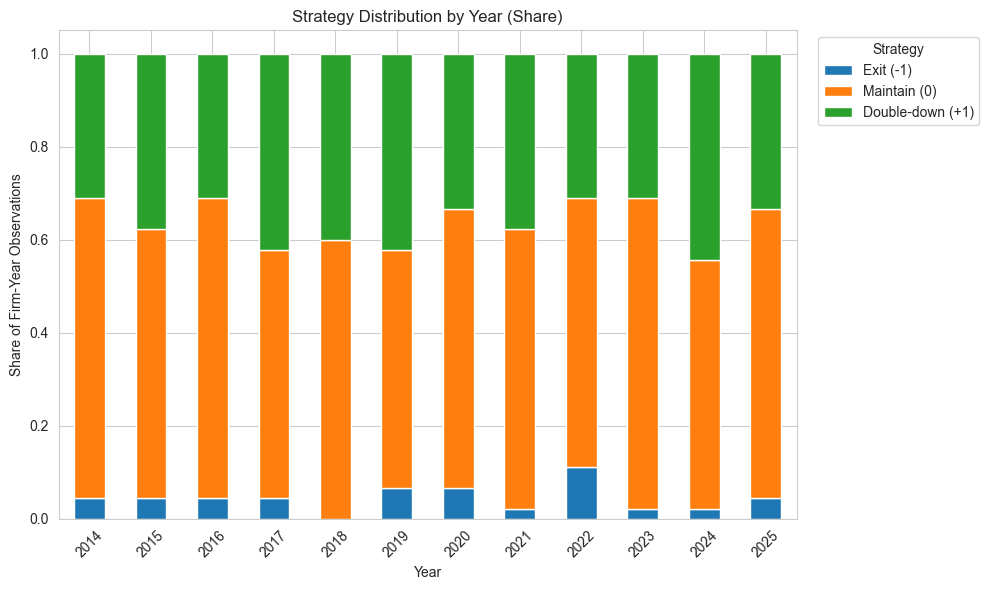

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Construct yearly strategy distribution shares
year_strategy = pd.crosstab(final_panel['year'], final_panel['strategy_Y'], normalize='index')

# Make sure all three categories exist
for col in [-1, 0, 1]:
    if col not in year_strategy.columns:
        year_strategy[col] = 0

# Reorder columns
year_strategy = year_strategy[[-1, 0, 1]]
year_strategy.columns = ['Exit (-1)', 'Maintain (0)', 'Double-down (+1)']


# 2. Plot stacked percentage bar chart

ax = year_strategy.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

ax.set_title('Strategy Distribution by Year (Share)')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Firm-Year Observations')
ax.legend(title='Strategy', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
# 7. Correlation matrix

print("\n" + "=" * 60)
print("Table 5: Correlation Matrix")
print("=" * 60)

corr_vars = [y_var, x_var,'size_lag1','leverage_lag1','roa_lag1','cash_ratio_lag1','ind_china_growth_lag1', 'lerner_index_lag1','policy_tension_lag1', 'china_gdp_growth_lag1', 'exchange_rate_lag1']

corr_vars = [c for c in corr_vars if c in final_panel.columns]

corr_matrix = final_panel[corr_vars].corr().round(3)
print(corr_matrix.to_string())


Table 5: Correlation Matrix
                       strategy_Y  sentiment_mean_lag1  size_lag1  leverage_lag1  roa_lag1  cash_ratio_lag1  ind_china_growth_lag1  lerner_index_lag1  policy_tension_lag1  china_gdp_growth_lag1  exchange_rate_lag1
strategy_Y                  1.000                0.117      0.092          0.118    -0.077           -0.030                 -0.066             -0.037               -0.008                 -0.025               0.033
sentiment_mean_lag1         0.117                1.000      0.108          0.044    -0.160           -0.086                 -0.143             -0.013               -0.089                  0.126              -0.135
size_lag1                   0.092                0.108      1.000          0.251    -0.252           -0.374                 -0.231             -0.007                0.091                 -0.069               0.108
leverage_lag1               0.118                0.044      0.251          1.000    -0.162           -0.316        

In [52]:
# 8. VIF

import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 1. Define regressors for multicollinearity diagnostics
main_var = 'sentiment_mean_lag1'

control_vars = [
    'size_lag1', 'leverage_lag1', 'roa_lag1', 'cash_ratio_lag1',
    'ind_china_growth_lag1', 'lerner_index_lag1',
    'policy_tension_lag1', 'china_gdp_growth_lag1', 'exchange_rate_lag1'
]
control_vars = [c for c in control_vars if c in final_panel.columns]

regressors = [main_var] + control_vars


# 2. Construct estimation sample for VIF analysis
vif_sample = final_panel.dropna(subset=regressors).copy()

for col in regressors:
    vif_sample[col] = pd.to_numeric(vif_sample[col], errors='coerce')

vif_sample = vif_sample.dropna(subset=regressors)


# 3. Compute Variance Inflation Factors (VIF)
X = vif_sample[regressors].astype(float)

vif_table = pd.DataFrame({
    'Variable': regressors,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})


vif_table = vif_table[['Variable', 'VIF']].sort_values('VIF', ascending=False)
vif_table['VIF'] = vif_table['VIF'].round(3)


# 4. Display results
print(vif_table.to_string(index=False))


             Variable    VIF
   exchange_rate_lag1 82.755
            size_lag1 34.875
china_gdp_growth_lag1 17.176
  policy_tension_lag1 13.102
        leverage_lag1  4.774
      cash_ratio_lag1  4.006
             roa_lag1  2.664
ind_china_growth_lag1  2.015
  sentiment_mean_lag1  1.370
    lerner_index_lag1  1.291


In [53]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 1. Define a low-multicollinearity baseline specification
y_var = 'strategy_Y'
x_var = 'sentiment_mean_lag1'

baseline_controls = [
    'size_lag1',
    'leverage_lag1',
    'roa_lag1',
    'cash_ratio_lag1',
    'ind_china_growth_lag1',
    'lerner_index_lag1',
    'policy_tension_lag1'
]

baseline_controls = [c for c in baseline_controls if c in final_panel.columns]
baseline_vars = [y_var, x_var] + baseline_controls

print("=== Baseline Specification Variables ===")
print(baseline_vars)


# 2. Construct the baseline regression sample
baseline_sample = final_panel.dropna(subset=baseline_vars).copy()

for col in baseline_vars:
    baseline_sample[col] = pd.to_numeric(baseline_sample[col], errors='coerce')

baseline_sample = baseline_sample.dropna(subset=baseline_vars)

print("\n=== Baseline Regression Sample Summary ===")
print(f"Rows: {len(baseline_sample)}")
print(f"Firms: {baseline_sample['ticker'].nunique()}")
print(f"Year range: {baseline_sample['year'].min()} - {baseline_sample['year'].max()}")

# 3. Run VIF diagnostics for the baseline specification
X = baseline_sample[[x_var] + baseline_controls].astype(float)

vif_table = pd.DataFrame({
    'Variable': [x_var] + baseline_controls,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_table['VIF'] = vif_table['VIF'].round(3)

print("\n" + "=" * 70)
print("Baseline VIF Diagnostics")
print("=" * 70)
print(vif_table.sort_values('VIF', ascending=False).to_string(index=False))

=== Baseline Specification Variables ===
['strategy_Y', 'sentiment_mean_lag1', 'size_lag1', 'leverage_lag1', 'roa_lag1', 'cash_ratio_lag1', 'ind_china_growth_lag1', 'lerner_index_lag1', 'policy_tension_lag1']

=== Baseline Regression Sample Summary ===
Rows: 488
Firms: 45
Year range: 2015 - 2025

Baseline VIF Diagnostics
             Variable    VIF
            size_lag1 11.201
  policy_tension_lag1  7.661
        leverage_lag1  4.578
      cash_ratio_lag1  3.128
             roa_lag1  2.537
ind_china_growth_lag1  1.986
  sentiment_mean_lag1  1.346
    lerner_index_lag1  1.194

Overall assessment:
The maximum VIF is 11.201, suggesting remaining multicollinearity concerns.


## 2-Empirical Analysis

In [69]:
# Drop STLAM from the panel
final_panel = final_panel[final_panel['ticker'] != 'STLAM'].copy()

print("=== After dropping STLAM ===")
print(f"Rows: {len(final_panel)}")
print(f"Firms: {final_panel['ticker'].nunique()}")
print(f"Years: {final_panel['year'].min()} - {final_panel['year'].max()}")

=== After dropping STLAM ===
Rows: 528
Firms: 44
Years: 2014 - 2025


In [70]:
baseline_vars = [
    'strategy_Y', 'sentiment_mean_lag1', 'size_lag1', 'leverage_lag1',
    'roa_lag1', 'cash_ratio_lag1', 'ind_china_growth_lag1',
    'lerner_index_lag1', 'policy_tension_lag1'
]

print("Rows in 2015-2025:", len(final_panel[final_panel['year'].between(2015, 2025)]))

for col in baseline_vars:
    missing_2015_2025 = final_panel.loc[
        final_panel['year'].between(2015, 2025), col
    ].isna().sum()
    print(f"{col}: {missing_2015_2025} missing")

Rows in 2015-2025: 484
strategy_Y: 0 missing
sentiment_mean_lag1: 0 missing
size_lag1: 0 missing
leverage_lag1: 0 missing
roa_lag1: 0 missing
cash_ratio_lag1: 0 missing
ind_china_growth_lag1: 0 missing
lerner_index_lag1: 0 missing
policy_tension_lag1: 0 missing


In [97]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from linearmodels.panel import PanelOLS
from linearmodels.iv import IV2SLS
from scipy import stats

# ------------------------------------------------------------
# 0. Setup
# ------------------------------------------------------------
y_var = 'strategy_Y'
x_var = 'sentiment_mean_lag1'

# Firm-level controls (baseline)
controls_firm = ['size_lag1', 'leverage_lag1', 'roa_lag1', 'cash_ratio_lag1']

# Industry-level controls
controls_industry = ['ind_china_growth_lag1', 'lerner_index_lag1']

# Macro controls (use separately due to collinearity)
controls_macro = ['policy_tension_lag1', 'china_gdp_growth_lag1', 'exchange_rate_lag1']

def stars(p):
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.1: return '*'
    return ''

def report(name, coef, pval, n=None):
    n_str = f", n={n}" if n else ""
    print(f"  {name}: β={coef:.4f}{stars(pval)}, p={pval:.4f}{n_str}")

#  1. Prepare Data

df = final_panel.sort_values(['ticker', 'year']).copy()

# Lagged dependent variable
df['strategy_Y_lag1'] = df.groupby('ticker')['strategy_Y'].shift(1)

# For ordered logit
df['strategy_ord'] = df['strategy_Y'].map({-1: 0, 0: 1, 1: 2})

# Binary outcomes
df['y_doubledown'] = (df['strategy_Y'] == 1).astype(int)
df['y_exit'] = (df['strategy_Y'] == -1).astype(int)

# Time indicators
df['post_2018'] = (df['year'] >= 2018).astype(int)
df['post_2019'] = (df['year'] >= 2019).astype(int)

# Industry dummies
df['ind_IT'] = (df['industry'] == 'IT').astype(int)
df['ind_Auto'] = (df['industry'] == 'Auto').astype(int)

### 1- Main Results

- Model 1: Baseline OLS with sentiment only
- Model 2: Model 1 + firm-level controls (size, leverage, ROA, cash ratio)
- Model 3: Model 2 + industry fixed effects
- Model 4: Model 2 + year fixed effects
- Model 5: Ordered logit with firm-level controls


In [103]:
print("\n" + "="*70)
print("TABLE 2: MAIN RESULTS")
print("="*70)

sample_main = df.dropna(subset=[y_var, x_var] + controls_firm).copy()
print(f"Sample: N={len(sample_main)}, Firms={sample_main['ticker'].nunique()}")

# Column 1: OLS baseline
X1 = sm.add_constant(sample_main[[x_var]].astype(float))
m1 = sm.OLS(sample_main[y_var], X1).fit(cov_type='cluster', cov_kwds={'groups': sample_main['ticker']})

# Column 2: + Firm controls
X2 = sm.add_constant(sample_main[[x_var] + controls_firm].astype(float))
m2 = sm.OLS(sample_main[y_var], X2).fit(cov_type='cluster', cov_kwds={'groups': sample_main['ticker']})

# Column 3: + Industry FE
X3 = sm.add_constant(sample_main[[x_var] + controls_firm + ['ind_IT', 'ind_Auto']].astype(float))
m3 = sm.OLS(sample_main[y_var], X3).fit(cov_type='cluster', cov_kwds={'groups': sample_main['ticker']})

# Column 4: + Year FE (via PanelOLS)
sample_panel = sample_main.set_index(['ticker', 'year'])
formula_yfe = f"{y_var} ~ 1 + {x_var} + " + " + ".join(controls_firm) + " + TimeEffects"
m4 = PanelOLS.from_formula(formula_yfe, data=sample_panel).fit(cov_type='clustered', cluster_entity=True)

# Column 5: Ordered Logit
X5 = sample_main[[x_var] + controls_firm].astype(float)
m5 = OrderedModel(sample_main['strategy_ord'], X5, distr='logit').fit(method='bfgs', disp=False)

# Build regression table
def format_coef(model, var, is_panel=False):
    """Format coefficient with stars and standard error"""
    try:
        coef = model.params[var]
        se = model.std_errors[var] if is_panel else model.bse[var]
        pval = model.pvalues[var]
        star = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
        return f"{coef:.4f}{star}", f"({se:.4f})"
    except:
        return "", ""

# Variables to report
report_vars = [x_var] + controls_firm + ['ind_IT', 'ind_Auto']

# Build table
table_rows = []
for var in report_vars:
    coef_row = [var]
    se_row = ['']

    # Column 1
    c, s = format_coef(m1, var)
    coef_row.append(c)
    se_row.append(s)

    # Column 2
    c, s = format_coef(m2, var)
    coef_row.append(c)
    se_row.append(s)

    # Column 3
    c, s = format_coef(m3, var)
    coef_row.append(c)
    se_row.append(s)

    # Column 4 (PanelOLS)
    c, s = format_coef(m4, var, is_panel=True)
    coef_row.append(c)
    se_row.append(s)

    # Column 5 (Ordered Logit)
    c, s = format_coef(m5, var)
    coef_row.append(c)
    se_row.append(s)

    table_rows.append(coef_row)
    table_rows.append(se_row)

# Create DataFrame
table_df = pd.DataFrame(table_rows, columns=['Variable', '(1)', '(2)', '(3)', '(4)', '(5)'])

# Add model statistics
stats_rows = [
    ['', '', '', '', '', ''],
    ['Firm Controls', 'No', 'Yes', 'Yes', 'Yes', 'Yes'],
    ['Industry FE', 'No', 'No', 'Yes', 'No', 'No'],
    ['Year FE', 'No', 'No', 'No', 'Yes', 'No'],
    ['Model', 'OLS', 'OLS', 'OLS', 'OLS', 'O-Logit'],
    ['N', f"{int(m1.nobs)}", f"{int(m2.nobs)}", f"{int(m3.nobs)}", f"{int(m4.nobs)}", f"{int(m5.nobs)}"],
    ['R-squared', f"{m1.rsquared:.3f}", f"{m2.rsquared:.3f}", f"{m3.rsquared:.3f}", f"{m4.rsquared:.3f}", ''],
    ['Pseudo R-sq', '', '', '', '', f"{m5.prsquared:.3f}"],
    ['Log-Likelihood', '', '', '', '', f"{m5.llf:.1f}"]
]

stats_df = pd.DataFrame(stats_rows, columns=['Variable', '(1)', '(2)', '(3)', '(4)', '(5)'])
table_full = pd.concat([table_df, stats_df], ignore_index=True)

print("\n" + "-"*90)
print("Panel A: Main Results")
print("-"*90)
print(table_full.to_string(index=False))

# Also print full summaries for reference
print("\n" + "-"*90)
print("Full Model Summaries")
print("-"*90)

print("\nColumn (1): OLS Baseline")
print(m1.summary())

print("\nColumn (2): OLS + Firm Controls")
print(m2.summary())

print("\nColumn (3): OLS + Industry FE")
print(m3.summary())

print("\nColumn (4): OLS + Year FE")
print(m4.summary)

print("\nColumn (5): Ordered Logit")
print(m5.summary())

# Export to Excel
table_full.to_excel("table2_main_results.xlsx", index=False)
print("\nTable exported to: table2_main_results.xlsx")


TABLE 2: MAIN RESULTS
Sample: N=484, Firms=44

------------------------------------------------------------------------------------------
Panel A: Main Results
------------------------------------------------------------------------------------------
           Variable      (1)      (2)      (3)      (4)      (5)
sentiment_mean_lag1 0.1768** 0.1546** 0.1638** 0.1665** 0.6149**
                    (0.0698) (0.0689) (0.0666) (0.0682) (0.2562)
          size_lag1            0.0200   0.0210   0.0196   0.0575
                             (0.0186) (0.0196) (0.0183) (0.0511)
      leverage_lag1            0.3424   0.3698   0.3554 1.3870**
                             (0.2860) (0.3155) (0.2901) (0.6243)
           roa_lag1           -0.2759  -0.2828  -0.2318  -0.8406
                             (0.3617) (0.3643) (0.3372) (1.1732)
    cash_ratio_lag1            0.2127   0.1813   0.2180   0.8218
                             (0.3075) (0.2973) (0.3109) (0.7652)
             ind_IT              

### 2- Robustness CHecks

In [111]:
# Panel A: Specification Checks

# 3.1 Control for lagged strategy
sample_lag = df.dropna(subset=[y_var, x_var, 'strategy_Y_lag1'] + controls_firm).copy()
X_lag = sm.add_constant(sample_lag[[x_var, 'strategy_Y_lag1'] + controls_firm].astype(float))
m_lag = sm.OLS(sample_lag[y_var], X_lag).fit(cov_type='cluster', cov_kwds={'groups': sample_lag['ticker']})

# 3.2 Two-way fixed effects
sample_twfe = df.dropna(subset=[y_var, x_var] + controls_firm).copy()
sample_twfe_panel = sample_twfe.set_index(['ticker', 'year'])
formula_twfe = f"{y_var} ~ 1 + {x_var} + " + " + ".join(controls_firm) + " + EntityEffects + TimeEffects"
m_twfe = PanelOLS.from_formula(formula_twfe, data=sample_twfe_panel).fit(cov_type='clustered', cluster_entity=True)

# 3.3 Trim extreme sentiment
sample_trim = df.dropna(subset=[y_var, x_var] + controls_firm).copy()
q01, q99 = sample_trim[x_var].quantile([0.01, 0.99])
sample_trim = sample_trim[(sample_trim[x_var] >= q01) & (sample_trim[x_var] <= q99)]
X_trim = sm.add_constant(sample_trim[[x_var] + controls_firm].astype(float))
m_trim = sm.OLS(sample_trim[y_var], X_trim).fit(cov_type='cluster', cov_kwds={'groups': sample_trim['ticker']})

# Build Panel A Table

print("\n" + "-"*90)
print("Panel A: Specification Checks")
print("-"*90)

report_vars_a = [x_var, 'strategy_Y_lag1'] + controls_firm

table_a_rows = []
for var in report_vars_a:
    coef_row = [var]
    se_row = ['']

    # (1) + Lagged Strategy
    c, s = format_coef(m_lag, var)
    coef_row.append(c)
    se_row.append(s)

    # (2) Two-way FE
    c, s = format_coef(m_twfe, var, is_panel=True)
    coef_row.append(c)
    se_row.append(s)

    # (3) Trimmed Sample
    c, s = format_coef(m_trim, var)
    coef_row.append(c)
    se_row.append(s)

    table_a_rows.append(coef_row)
    table_a_rows.append(se_row)

table_a = pd.DataFrame(table_a_rows, columns=['Variable', '(1) +Lag DV', '(2) Two-way FE', '(3) Trimmed'])

stats_a = pd.DataFrame([
    ['', '', '', ''],
    ['Lagged Strategy', 'Yes', 'No', 'No'],
    ['Firm FE', 'No', 'Yes', 'No'],
    ['Year FE', 'No', 'Yes', 'No'],
    ['Trimmed 1%/99%', 'No', 'No', 'Yes'],
    ['N', f"{int(m_lag.nobs)}", f"{int(m_twfe.nobs)}", f"{int(m_trim.nobs)}"],
    ['R-squared', f"{m_lag.rsquared:.3f}", f"{m_twfe.rsquared:.3f}", f"{m_trim.rsquared:.3f}"]
], columns=['Variable', '(1) +Lag DV', '(2) Two-way FE', '(3) Trimmed'])

table_a_full = pd.concat([table_a, stats_a], ignore_index=True)
print(table_a_full.to_string(index=False))



------------------------------------------------------------------------------------------
Panel A: Specification Checks
------------------------------------------------------------------------------------------
           Variable (1) +Lag DV (2) Two-way FE (3) Trimmed
sentiment_mean_lag1    0.1140**       0.1121**    0.1546**
                       (0.0538)       (0.0537)    (0.0689)
    strategy_Y_lag1   0.3343***                           
                       (0.0644)                           
          size_lag1      0.0117         0.1256      0.0200
                       (0.0137)       (0.1052)    (0.0186)
      leverage_lag1      0.1949         0.1796      0.3424
                       (0.1918)       (0.3826)    (0.2860)
           roa_lag1     -0.2492         0.0708     -0.2759
                       (0.2663)       (0.4566)    (0.3617)
    cash_ratio_lag1      0.1158      0.9921***      0.2127
                       (0.2089)       (0.3524)    (0.3075)
                    

In [112]:
# Panel B: Binary Outcomes

sample_bin = df.dropna(subset=[y_var, x_var] + controls_firm).copy()
X_bin = sm.add_constant(sample_bin[[x_var] + controls_firm].astype(float))

m_dd = sm.Logit(sample_bin['y_doubledown'], X_bin).fit(disp=0)
m_exit = sm.Logit(sample_bin['y_exit'], X_bin).fit(disp=0)



# Build Panel B Table

print("\n" + "-"*90)
print("Panel B: Binary Outcomes (Logit)")
print("-"*90)

report_vars_b = [x_var] + controls_firm

table_b_rows = []
for var in report_vars_b:
    coef_row = [var]
    se_row = ['']

    # (4) Double-down
    c, s = format_coef(m_dd, var)
    coef_row.append(c)
    se_row.append(s)

    # (5) Exit
    c, s = format_coef(m_exit, var)
    coef_row.append(c)
    se_row.append(s)

    table_b_rows.append(coef_row)
    table_b_rows.append(se_row)

table_b = pd.DataFrame(table_b_rows, columns=['Variable', '(4) Double-down', '(5) Exit'])

stats_b = pd.DataFrame([
    ['', '', ''],
    ['Dependent Variable', 'DD=1 vs Others', 'Exit=1 vs Others'],
    ['Model', 'Logit', 'Logit'],
    ['N', f"{int(m_dd.nobs)}", f"{int(m_exit.nobs)}"],
    ['Pseudo R-sq', f"{m_dd.prsquared:.3f}", f"{m_exit.prsquared:.3f}"],
    ['Log-Likelihood', f"{m_dd.llf:.1f}", f"{m_exit.llf:.1f}"]
], columns=['Variable', '(4) Double-down', '(5) Exit'])

table_b_full = pd.concat([table_b, stats_b], ignore_index=True)
print(table_b_full.to_string(index=False))



------------------------------------------------------------------------------------------
Panel B: Binary Outcomes (Logit)
------------------------------------------------------------------------------------------
           Variable (4) Double-down         (5) Exit
sentiment_mean_lag1       0.7067***           0.0761
                           (0.2704)         (0.6502)
          size_lag1          0.0214       -0.4685***
                           (0.0527)         (0.1501)
      leverage_lag1        1.5852**           0.5298
                           (0.6405)         (1.2892)
           roa_lag1         -0.6982           2.7912
                           (1.2544)         (2.5499)
    cash_ratio_lag1          0.9689           0.0957
                           (0.7865)         (1.5207)
                                                    
 Dependent Variable  DD=1 vs Others Exit=1 vs Others
              Model           Logit            Logit
                  N             484       

In [113]:
# Panel C: Alternative Macro Controls
macro_models = {}
for macro_var in controls_macro:
    if macro_var in df.columns:
        sample_m = df.dropna(subset=[y_var, x_var, macro_var] + controls_firm).copy()
        X_m = sm.add_constant(sample_m[[x_var] + controls_firm + [macro_var]].astype(float))
        m_m = sm.OLS(sample_m[y_var], X_m).fit(cov_type='cluster', cov_kwds={'groups': sample_m['ticker']})
        macro_models[macro_var] = {'model': m_m, 'n': len(sample_m)}


# Build Panel C Table

print("\n" + "-"*90)
print("Panel C: Alternative Macro Controls")
print("-"*90)

# Get macro variable names that exist
macro_vars_exist = [v for v in controls_macro if v in macro_models]

report_vars_c = [x_var] + controls_firm + macro_vars_exist

table_c_rows = []
for var in report_vars_c:
    coef_row = [var]
    se_row = ['']

    for macro_var in macro_vars_exist:
        m_m = macro_models[macro_var]['model']
        c, s = format_coef(m_m, var)
        coef_row.append(c)
        se_row.append(s)

    table_c_rows.append(coef_row)
    table_c_rows.append(se_row)

col_names = ['Variable'] + [f"(+{v.replace('_lag1','')})" for v in macro_vars_exist]
table_c = pd.DataFrame(table_c_rows, columns=col_names)

stats_c_data = [['', *['' for _ in macro_vars_exist]]]
stats_c_data.append(['Macro Control'] + macro_vars_exist)
stats_c_data.append(['Year FE'] + ['No' for _ in macro_vars_exist])
stats_c_data.append(['N'] + [f"{macro_models[v]['n']}" for v in macro_vars_exist])
stats_c_data.append(['R-squared'] + [f"{macro_models[v]['model'].rsquared:.3f}" for v in macro_vars_exist])

stats_c = pd.DataFrame(stats_c_data, columns=col_names)
table_c_full = pd.concat([table_c, stats_c], ignore_index=True)
print(table_c_full.to_string(index=False))


------------------------------------------------------------------------------------------
Panel C: Alternative Macro Controls
------------------------------------------------------------------------------------------
             Variable   (+policy_tension)   (+china_gdp_growth)   (+exchange_rate)
  sentiment_mean_lag1            0.1547**              0.1620**           0.1645**
                                 (0.0690)              (0.0703)           (0.0688)
            size_lag1              0.0200                0.0193             0.0187
                                 (0.0187)              (0.0184)           (0.0185)
        leverage_lag1              0.3423                0.3414             0.3389
                                 (0.2876)              (0.2864)           (0.2866)
             roa_lag1             -0.2767               -0.3064            -0.3343
                                 (0.3677)              (0.3668)           (0.3521)
      cash_ratio_lag1             

In [114]:
# Full Model Summaries

print("\n" + "-"*90)
print("Full Model Summaries")
print("-"*90)

print("\n(1) OLS + Lagged Strategy")
print(m_lag.summary())

print("\n(2) Two-way Fixed Effects")
print(m_twfe.summary)

print("\n(3) Trimmed Sample")
print(m_trim.summary())

print("\n(4) Logit: Double-down vs Others")
print(m_dd.summary())

print("\n(5) Logit: Exit vs Others")
print(m_exit.summary())

for macro_var in macro_vars_exist:
    print(f"\n(+) Macro Control: {macro_var}")
    print(macro_models[macro_var]['model'].summary())

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
with pd.ExcelWriter("table3_robustness.xlsx") as writer:
    table_a_full.to_excel(writer, sheet_name='Panel_A_Specifications', index=False)
    table_b_full.to_excel(writer, sheet_name='Panel_B_Binary', index=False)
    table_c_full.to_excel(writer, sheet_name='Panel_C_Macro', index=False)

print("\nTable exported to: table3_robustness.xlsx")


------------------------------------------------------------------------------------------
Full Model Summaries
------------------------------------------------------------------------------------------

(1) OLS + Lagged Strategy
                            OLS Regression Results                            
Dep. Variable:             strategy_Y   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     8.667
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           3.38e-06
Time:                        04:32:20   Log-Likelihood:                -368.75
No. Observations:                 484   AIC:                             751.5
Df Residuals:                     477   BIC:                             780.8
Df Model:                           6                                         
Covariance Type:              cluster                     

### 3-Heterogeneity

In [115]:
sample_het = df.dropna(subset=[y_var, x_var] + controls_firm).copy()

# Panel A: By Industry
industry_models = {}
for ind in ['IT', 'Pharma', 'Auto']:
    sub = sample_het[sample_het['industry'] == ind]
    if len(sub) >= 30:
        X_sub = sm.add_constant(sub[[x_var] + controls_firm].astype(float))
        m_sub = sm.OLS(sub[y_var], X_sub).fit(cov_type='cluster', cov_kwds={'groups': sub['ticker']})
        industry_models[ind] = {'model': m_sub, 'n': len(sub), 'firms': sub['ticker'].nunique()}

# Build Panel A Table: By Industry
print("\n" + "-"*90)
print("Panel A: By Industry")
print("-"*90)

report_vars = [x_var] + controls_firm
industries = list(industry_models.keys())

table_a_rows = []
for var in report_vars:
    coef_row = [var]
    se_row = ['']
    for ind in industries:
        m = industry_models[ind]['model']
        c, s = format_coef(m, var)
        coef_row.append(c)
        se_row.append(s)
    table_a_rows.append(coef_row)
    table_a_rows.append(se_row)

table_a = pd.DataFrame(table_a_rows, columns=['Variable'] + industries)

stats_a = pd.DataFrame([
    ['', *['' for _ in industries]],
    ['N', *[f"{industry_models[ind]['n']}" for ind in industries]],
    ['Firms', *[f"{industry_models[ind]['firms']}" for ind in industries]],
    ['R-squared', *[f"{industry_models[ind]['model'].rsquared:.3f}" for ind in industries]]
], columns=['Variable'] + industries)

table_a_full = pd.concat([table_a, stats_a], ignore_index=True)
print(table_a_full.to_string(index=False))


------------------------------------------------------------------------------------------
Panel A: By Industry
------------------------------------------------------------------------------------------
           Variable       IT    Pharma     Auto
sentiment_mean_lag1   0.1399    0.1167   0.1979
                    (0.0953)  (0.1159) (0.1243)
          size_lag1  -0.0136    0.0331 0.0543**
                    (0.0417)  (0.0349) (0.0264)
      leverage_lag1   0.3374 0.8877***  -0.5913
                    (0.5031)  (0.2594) (0.7164)
           roa_lag1  -0.3061   -0.6931  -0.3429
                    (0.4165)  (1.3117) (1.4126)
    cash_ratio_lag1   0.1880   -0.2573 1.3564**
                    (0.4022)  (0.2464) (0.6254)
                                               
                  N      231       154       99
              Firms       21        14        9
          R-squared    0.025     0.065    0.120


In [116]:
# Panel B: By Time Period
period_models = {}
for period, label in [(0, 'Pre-2018'), (1, 'Post-2018')]:
    sub = sample_het[sample_het['post_2018'] == period]
    if len(sub) >= 30:
        X_sub = sm.add_constant(sub[[x_var] + controls_firm].astype(float))
        m_sub = sm.OLS(sub[y_var], X_sub).fit(cov_type='cluster', cov_kwds={'groups': sub['ticker']})
        period_models[label] = {'model': m_sub, 'n': len(sub), 'firms': sub['ticker'].nunique()}

# Build Panel B Table: By Time Period
print("\n" + "-"*90)
print("Panel B: By Time Period")
print("-"*90)

periods = list(period_models.keys())

table_b_rows = []
for var in report_vars:
    coef_row = [var]
    se_row = ['']
    for period in periods:
        m = period_models[period]['model']
        c, s = format_coef(m, var)
        coef_row.append(c)
        se_row.append(s)
    table_b_rows.append(coef_row)
    table_b_rows.append(se_row)

table_b = pd.DataFrame(table_b_rows, columns=['Variable'] + periods)

stats_b = pd.DataFrame([
    ['', *['' for _ in periods]],
    ['N', *[f"{period_models[p]['n']}" for p in periods]],
    ['Firms', *[f"{period_models[p]['firms']}" for p in periods]],
    ['R-squared', *[f"{period_models[p]['model'].rsquared:.3f}" for p in periods]]
], columns=['Variable'] + periods)

table_b_full = pd.concat([table_b, stats_b], ignore_index=True)
print(table_b_full.to_string(index=False))


------------------------------------------------------------------------------------------
Panel B: By Time Period
------------------------------------------------------------------------------------------
           Variable Pre-2018 Post-2018
sentiment_mean_lag1   0.0613  0.1772**
                    (0.1263)  (0.0755)
          size_lag1 0.0535**    0.0070
                    (0.0257)  (0.0205)
      leverage_lag1  -0.0073    0.4721
                    (0.3842)  (0.3132)
           roa_lag1  -0.7108   -0.2885
                    (1.0091)  (0.3893)
    cash_ratio_lag1   0.4015    0.1823
                    (0.4218)  (0.3944)
                                      
                  N      132       352
              Firms       44        44
          R-squared    0.044     0.037


In [117]:
# Panel C: By China Revenue Exposure
exposure_models = {}
if 'china_revenue_lag1' in df.columns:
    sub_rev = sample_het.dropna(subset=['china_revenue_lag1']).copy()
    median_rev = sub_rev['china_revenue_lag1'].median()

    sub_low = sub_rev[sub_rev['china_revenue_lag1'] <= median_rev]
    sub_high = sub_rev[sub_rev['china_revenue_lag1'] > median_rev]

    for sub, label in [(sub_low, 'Low Exposure'), (sub_high, 'High Exposure')]:
        if len(sub) >= 30:
            X_sub = sm.add_constant(sub[[x_var] + controls_firm].astype(float))
            m_sub = sm.OLS(sub[y_var], X_sub).fit(cov_type='cluster', cov_kwds={'groups': sub['ticker']})
            exposure_models[label] = {'model': m_sub, 'n': len(sub), 'firms': sub['ticker'].nunique()}

# Build Panel C Table: By China Exposure
# ------------------------------------------------------------
print("\n" + "-"*90)
print("Panel C: By China Revenue Exposure")
print("-"*90)

if exposure_models:
    exposures = list(exposure_models.keys())

    table_c_rows = []
    for var in report_vars:
        coef_row = [var]
        se_row = ['']
        for exp in exposures:
            m = exposure_models[exp]['model']
            c, s = format_coef(m, var)
            coef_row.append(c)
            se_row.append(s)
        table_c_rows.append(coef_row)
        table_c_rows.append(se_row)

    table_c = pd.DataFrame(table_c_rows, columns=['Variable'] + exposures)

    stats_c = pd.DataFrame([
        ['', *['' for _ in exposures]],
        ['N', *[f"{exposure_models[e]['n']}" for e in exposures]],
        ['Firms', *[f"{exposure_models[e]['firms']}" for e in exposures]],
        ['R-squared', *[f"{exposure_models[e]['model'].rsquared:.3f}" for e in exposures]]
    ], columns=['Variable'] + exposures)

    table_c_full = pd.concat([table_c, stats_c], ignore_index=True)
    print(table_c_full.to_string(index=False))
else:
    print("China revenue data not available")
    table_c_full = None


------------------------------------------------------------------------------------------
Panel C: By China Revenue Exposure
------------------------------------------------------------------------------------------
           Variable Low Exposure High Exposure
sentiment_mean_lag1     0.2372**        0.2028
                        (0.0982)      (0.1410)
          size_lag1       0.0792       -0.1166
                        (0.0500)      (0.0750)
      leverage_lag1       0.6214        0.2513
                        (0.4738)      (0.6191)
           roa_lag1       0.8283        0.0149
                        (0.5999)      (0.5633)
    cash_ratio_lag1     0.8029**       -0.5780
                        (0.3400)      (0.5898)
                                              
                  N          132           132
              Firms           19            16
          R-squared        0.109         0.079


In [118]:
# Panel D: Interaction Models

sample_int = sample_het.copy()

# Interaction 1: Post-2018
sample_int['sent_x_post2018'] = sample_int[x_var] * sample_int['post_2018']
X_int1 = sm.add_constant(sample_int[[x_var, 'post_2018', 'sent_x_post2018'] + controls_firm].astype(float))
m_int_time = sm.OLS(sample_int[y_var], X_int1).fit(cov_type='cluster', cov_kwds={'groups': sample_int['ticker']})

# Interaction 2: Industry (IT vs others)
sample_int['sent_x_IT'] = sample_int[x_var] * sample_int['ind_IT']
X_int2 = sm.add_constant(sample_int[[x_var, 'ind_IT', 'sent_x_IT'] + controls_firm].astype(float))
m_int_ind = sm.OLS(sample_int[y_var], X_int2).fit(cov_type='cluster', cov_kwds={'groups': sample_int['ticker']})

# Interaction 3: China exposure (if available)
m_int_exp = None
if 'china_revenue_lag1' in sample_int.columns:
    sample_int_exp = sample_int.dropna(subset=['china_revenue_lag1']).copy()
    sample_int_exp['high_exposure'] = (sample_int_exp['china_revenue_lag1'] > sample_int_exp['china_revenue_lag1'].median()).astype(int)
    sample_int_exp['sent_x_highexp'] = sample_int_exp[x_var] * sample_int_exp['high_exposure']
    X_int3 = sm.add_constant(sample_int_exp[[x_var, 'high_exposure', 'sent_x_highexp'] + controls_firm].astype(float))
    m_int_exp = sm.OLS(sample_int_exp[y_var], X_int3).fit(cov_type='cluster', cov_kwds={'groups': sample_int_exp['ticker']})

# ------------------------------------------------------------
# Build Panel D Table: Interaction Effects
# ------------------------------------------------------------
print("\n" + "-"*90)
print("Panel D: Interaction Effects")
print("-"*90)

# Variables for interaction models
int_vars_time = [x_var, 'post_2018', 'sent_x_post2018'] + controls_firm
int_vars_ind = [x_var, 'ind_IT', 'sent_x_IT'] + controls_firm
int_vars_exp = [x_var, 'high_exposure', 'sent_x_highexp'] + controls_firm if m_int_exp else []

# Determine columns
int_cols = ['(1) Time', '(2) Industry']
int_models = [m_int_time, m_int_ind]
if m_int_exp:
    int_cols.append('(3) Exposure')
    int_models.append(m_int_exp)

# All possible variables
all_int_vars = list(dict.fromkeys([x_var, 'post_2018', 'sent_x_post2018',
                                    'ind_IT', 'sent_x_IT',
                                    'high_exposure', 'sent_x_highexp'] + controls_firm))

table_d_rows = []
for var in all_int_vars:
    coef_row = [var]
    se_row = ['']

    # Time interaction model
    c, s = format_coef(m_int_time, var)
    coef_row.append(c)
    se_row.append(s)

    # Industry interaction model
    c, s = format_coef(m_int_ind, var)
    coef_row.append(c)
    se_row.append(s)

    # Exposure interaction model
    if m_int_exp:
        c, s = format_coef(m_int_exp, var)
        coef_row.append(c)
        se_row.append(s)

    table_d_rows.append(coef_row)
    table_d_rows.append(se_row)

table_d = pd.DataFrame(table_d_rows, columns=['Variable'] + int_cols)

stats_d_data = [
    ['', *['' for _ in int_cols]],
    ['Interaction', 'Sentiment×Post2018', 'Sentiment×IT', 'Sentiment×HighExp' if m_int_exp else ''],
    ['N', f"{int(m_int_time.nobs)}", f"{int(m_int_ind.nobs)}", f"{int(m_int_exp.nobs)}" if m_int_exp else ''],
    ['R-squared', f"{m_int_time.rsquared:.3f}", f"{m_int_ind.rsquared:.3f}", f"{m_int_exp.rsquared:.3f}" if m_int_exp else '']
]

stats_d = pd.DataFrame(stats_d_data, columns=['Variable'] + int_cols)
table_d_full = pd.concat([table_d, stats_d], ignore_index=True)
print(table_d_full.to_string(index=False))



------------------------------------------------------------------------------------------
Panel D: Interaction Effects
------------------------------------------------------------------------------------------
           Variable           (1) Time (2) Industry      (3) Exposure
sentiment_mean_lag1             0.0931      0.1850*         0.2833***
                              (0.1293)     (0.0983)          (0.1084)
          post_2018            -0.0088                               
                              (0.0658)                               
    sent_x_post2018             0.0831                               
                              (0.1505)                               
             ind_IT                          0.0391                  
                                           (0.1030)                  
          sent_x_IT                         -0.0385                  
                                           (0.1380)                  
      high_exposur

In [119]:

# Full Model Summaries

print("\n" + "-"*90)
print("Full Model Summaries")
print("-"*90)

print("\n--- Panel A: By Industry ---")
for ind in industries:
    print(f"\n{ind}:")
    print(industry_models[ind]['model'].summary())

print("\n--- Panel B: By Time Period ---")
for period in periods:
    print(f"\n{period}:")
    print(period_models[period]['model'].summary())

print("\n--- Panel C: By China Exposure ---")
if exposure_models:
    for exp in exposures:
        print(f"\n{exp}:")
        print(exposure_models[exp]['model'].summary())

print("\n--- Panel D: Interaction Models ---")
print("\n(1) Time Interaction:")
print(m_int_time.summary())

print("\n(2) Industry Interaction:")
print(m_int_ind.summary())

if m_int_exp:
    print("\n(3) Exposure Interaction:")
    print(m_int_exp.summary())

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
with pd.ExcelWriter("table4_heterogeneity.xlsx") as writer:
    table_a_full.to_excel(writer, sheet_name='Panel_A_Industry', index=False)
    table_b_full.to_excel(writer, sheet_name='Panel_B_Time', index=False)
    if table_c_full is not None:
        table_c_full.to_excel(writer, sheet_name='Panel_C_Exposure', index=False)
    table_d_full.to_excel(writer, sheet_name='Panel_D_Interaction', index=False)

print("\nTable exported to: table4_heterogeneity.xlsx")


------------------------------------------------------------------------------------------
Full Model Summaries
------------------------------------------------------------------------------------------

--- Panel A: By Industry ---

IT:
                            OLS Regression Results                            
Dep. Variable:             strategy_Y   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.064
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.409
Time:                        04:34:37   Log-Likelihood:                -180.83
No. Observations:                 231   AIC:                             373.7
Df Residuals:                     225   BIC:                             394.3
Df Model:                           5                                         
Covariance Type:              cluster             

### 4- Endogenity & identification

In [120]:
# ------------------------------------------------------------
# Panel A: Reverse Causality
# ------------------------------------------------------------
df['sentiment_current'] = df['sentiment_mean']
sample_rev = df.dropna(subset=['sentiment_current', 'strategy_Y_lag1'] + controls_firm).copy()
X_rev = sm.add_constant(sample_rev[['strategy_Y_lag1'] + controls_firm].astype(float))
m_rev = sm.OLS(sample_rev['sentiment_current'], X_rev).fit(cov_type='cluster', cov_kwds={'groups': sample_rev['ticker']})

# Build Panel A Table: Reverse Causality
# ------------------------------------------------------------
print("\n" + "-"*90)
print("Panel A: Reverse Causality Test")
print("Dependent Variable: Sentiment(t)")
print("-"*90)

report_vars_a = ['strategy_Y_lag1'] + controls_firm

table_a_rows = []
for var in report_vars_a:
    coef_row = [var]
    se_row = ['']
    c, s = format_coef(m_rev, var)
    coef_row.append(c)
    se_row.append(s)
    table_a_rows.append(coef_row)
    table_a_rows.append(se_row)

table_a = pd.DataFrame(table_a_rows, columns=['Variable', 'Strategy(t-1)→Sentiment(t)'])

stats_a = pd.DataFrame([
    ['', ''],
    ['Dependent Var', 'Sentiment(t)'],
    ['N', f"{int(m_rev.nobs)}"],
    ['R-squared', f"{m_rev.rsquared:.3f}"]
], columns=['Variable', 'Strategy(t-1)→Sentiment(t)'])

table_a_full = pd.concat([table_a, stats_a], ignore_index=True)
print(table_a_full.to_string(index=False))



------------------------------------------------------------------------------------------
Panel A: Reverse Causality Test
Dependent Variable: Sentiment(t)
------------------------------------------------------------------------------------------
       Variable Strategy(t-1)→Sentiment(t)
strategy_Y_lag1                   0.0838**
                                  (0.0336)
      size_lag1                     0.0116
                                  (0.0141)
  leverage_lag1                    -0.1355
                                  (0.1790)
       roa_lag1                    -0.2763
                                  (0.2927)
cash_ratio_lag1                    -0.2757
                                  (0.1678)
                                          
  Dependent Var               Sentiment(t)
              N                        484
      R-squared                      0.043


In [121]:
# ------------------------------------------------------------
# Panel B: Placebo Test
# ------------------------------------------------------------
df['sentiment_lead1'] = df.groupby('ticker')['sentiment_mean'].shift(-1)
sample_placebo = df.dropna(subset=[y_var, 'sentiment_lead1'] + controls_firm).copy()
X_placebo = sm.add_constant(sample_placebo[['sentiment_lead1'] + controls_firm].astype(float))
m_placebo = sm.OLS(sample_placebo[y_var], X_placebo).fit(cov_type='cluster', cov_kwds={'groups': sample_placebo['ticker']})

# Placebo with controls for current sentiment
sample_placebo2 = df.dropna(subset=[y_var, 'sentiment_lead1', 'sentiment_mean'] + controls_firm).copy()
X_placebo2 = sm.add_constant(sample_placebo2[['sentiment_lead1', 'sentiment_mean'] + controls_firm].astype(float))
m_placebo2 = sm.OLS(sample_placebo2[y_var], X_placebo2).fit(cov_type='cluster', cov_kwds={'groups': sample_placebo2['ticker']})


# ------------------------------------------------------------

# ------------------------------------------------------------
# Build Panel B Table: Placebo Test
# ------------------------------------------------------------
print("\n" + "-"*90)
print("Panel B: Placebo Test")
print("Dependent Variable: Strategy(t)")
print("-"*90)

report_vars_b = ['sentiment_lead1', 'sentiment_mean'] + controls_firm

table_b_rows = []
for var in report_vars_b:
    coef_row = [var]
    se_row = ['']

    # (1) Lead only
    c, s = format_coef(m_placebo, var)
    coef_row.append(c)
    se_row.append(s)

    # (2) Lead + Current
    c, s = format_coef(m_placebo2, var)
    coef_row.append(c)
    se_row.append(s)

    table_b_rows.append(coef_row)
    table_b_rows.append(se_row)

table_b = pd.DataFrame(table_b_rows, columns=['Variable', '(1) Lead Only', '(2) Lead + Current'])

stats_b = pd.DataFrame([
    ['', '', ''],
    ['N', f"{int(m_placebo.nobs)}", f"{int(m_placebo2.nobs)}"],
    ['R-squared', f"{m_placebo.rsquared:.3f}", f"{m_placebo2.rsquared:.3f}"]
], columns=['Variable', '(1) Lead Only', '(2) Lead + Current'])

table_b_full = pd.concat([table_b, stats_b], ignore_index=True)
print(table_b_full.to_string(index=False))

# Interpretation
print("\nInterpretation:")
if m_placebo.pvalues['sentiment_lead1'] < 0.1:
    print("  Lead sentiment predicts current strategy - potential confounding")
else:
    print("  Lead sentiment does NOT predict current strategy - supports causality")


------------------------------------------------------------------------------------------
Panel B: Placebo Test
Dependent Variable: Strategy(t)
------------------------------------------------------------------------------------------
       Variable (1) Lead Only (2) Lead + Current
sentiment_lead1     0.2186***          0.1865***
                     (0.0706)           (0.0711)
 sentiment_mean                           0.1052
                                        (0.0756)
      size_lag1        0.0190             0.0181
                     (0.0194)           (0.0191)
  leverage_lag1        0.3580             0.3624
                     (0.2986)           (0.2955)
       roa_lag1       -0.1601            -0.1276
                     (0.4155)           (0.4090)
cash_ratio_lag1        0.2582             0.2741
                     (0.3166)           (0.3139)
                                                
              N           440                440
      R-squared         0.03

In [122]:
# ------------------------------------------------------------
# Panel C: Instrumental Variables
# ------------------------------------------------------------
# Construct IVs
df['sentiment_lag2'] = df.groupby('ticker')['sentiment_mean'].shift(2)
df['sentiment_lag3'] = df.groupby('ticker')['sentiment_mean'].shift(3)

ind_mean = df.groupby(['industry', 'year'])['sentiment_mean'].transform('mean')
ind_count = df.groupby(['industry', 'year'])['sentiment_mean'].transform('count')
df['iv_industry'] = (ind_mean * ind_count - df['sentiment_mean']) / (ind_count - 1)
df.loc[ind_count <= 1, 'iv_industry'] = np.nan
df['iv_industry_lag1'] = df.groupby('ticker')['iv_industry'].shift(1)

sample_iv = df.dropna(subset=[y_var, x_var, 'sentiment_lag2', 'iv_industry_lag1'] + controls_firm).copy()

# OLS on IV sample (for comparison)
X_ols_iv = sm.add_constant(sample_iv[[x_var] + controls_firm].astype(float))
m_ols_iv = sm.OLS(sample_iv[y_var], X_ols_iv).fit(cov_type='cluster', cov_kwds={'groups': sample_iv['ticker']})

# First stage: lag2
X_fs_lag2 = sm.add_constant(sample_iv[['sentiment_lag2'] + controls_firm].astype(float))
m_fs_lag2 = sm.OLS(sample_iv[x_var], X_fs_lag2).fit()

# First stage: industry IV
X_fs_ind = sm.add_constant(sample_iv[['iv_industry_lag1'] + controls_firm].astype(float))
m_fs_ind = sm.OLS(sample_iv[x_var], X_fs_ind).fit()

# First stage: both IVs
X_fs_both = sm.add_constant(sample_iv[['sentiment_lag2', 'iv_industry_lag1'] + controls_firm].astype(float))
m_fs_both = sm.OLS(sample_iv[x_var], X_fs_both).fit()

# 2SLS: lag2 IV
m_2sls_lag2 = IV2SLS(
    dependent=sample_iv[y_var].astype(float),
    exog=sm.add_constant(sample_iv[controls_firm].astype(float)),
    endog=sample_iv[[x_var]].astype(float),
    instruments=sample_iv[['sentiment_lag2']].astype(float)
).fit(cov_type='clustered', clusters=sample_iv['ticker'])

# 2SLS: industry IV
m_2sls_ind = IV2SLS(
    dependent=sample_iv[y_var].astype(float),
    exog=sm.add_constant(sample_iv[controls_firm].astype(float)),
    endog=sample_iv[[x_var]].astype(float),
    instruments=sample_iv[['iv_industry_lag1']].astype(float)
).fit(cov_type='clustered', clusters=sample_iv['ticker'])

# 2SLS: both IVs
m_2sls_both = IV2SLS(
    dependent=sample_iv[y_var].astype(float),
    exog=sm.add_constant(sample_iv[controls_firm].astype(float)),
    endog=sample_iv[[x_var]].astype(float),
    instruments=sample_iv[['sentiment_lag2', 'iv_industry_lag1']].astype(float)
).fit(cov_type='clustered', clusters=sample_iv['ticker'])


# ------------------------------------------------------------
# Build Panel C Table: Instrumental Variables
# ------------------------------------------------------------
print("\n" + "-"*90)
print("Panel C: Instrumental Variables")
print("-"*90)

print(f"\nIV Sample: N={len(sample_iv)}, Firms={sample_iv['ticker'].nunique()}")

# First Stage Results
print("\nFirst Stage Results:")
print(f"  IV = Sentiment(t-2):     coef={m_fs_lag2.params['sentiment_lag2']:.4f}, t={m_fs_lag2.tvalues['sentiment_lag2']:.2f}, F={m_fs_lag2.fvalue:.2f}")
print(f"  IV = Industry Sentiment: coef={m_fs_ind.params['iv_industry_lag1']:.4f}, t={m_fs_ind.tvalues['iv_industry_lag1']:.2f}, F={m_fs_ind.fvalue:.2f}")

# Second Stage Table
report_vars_c = [x_var] + controls_firm

table_c_rows = []
for var in report_vars_c:
    coef_row = [var]
    se_row = ['']

    # OLS
    c, s = format_coef(m_ols_iv, var)
    coef_row.append(c)
    se_row.append(s)

    # 2SLS lag2
    try:
        coef = m_2sls_lag2.params[var]
        se = m_2sls_lag2.std_errors[var]
        pval = m_2sls_lag2.pvalues[var]
        star = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
        coef_row.append(f"{coef:.4f}{star}")
        se_row.append(f"({se:.4f})")
    except:
        coef_row.append('')
        se_row.append('')

    # 2SLS industry
    try:
        coef = m_2sls_ind.params[var]
        se = m_2sls_ind.std_errors[var]
        pval = m_2sls_ind.pvalues[var]
        star = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
        coef_row.append(f"{coef:.4f}{star}")
        se_row.append(f"({se:.4f})")
    except:
        coef_row.append('')
        se_row.append('')

    # 2SLS both
    try:
        coef = m_2sls_both.params[var]
        se = m_2sls_both.std_errors[var]
        pval = m_2sls_both.pvalues[var]
        star = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
        coef_row.append(f"{coef:.4f}{star}")
        se_row.append(f"({se:.4f})")
    except:
        coef_row.append('')
        se_row.append('')

    table_c_rows.append(coef_row)
    table_c_rows.append(se_row)

table_c = pd.DataFrame(table_c_rows, columns=['Variable', '(1) OLS', '(2) 2SLS Lag2', '(3) 2SLS Industry', '(4) 2SLS Both'])

stats_c = pd.DataFrame([
    ['', '', '', '', ''],
    ['Instrument', '-', 'Sentiment(t-2)', 'Industry Avg', 'Both'],
    ['First-stage F', '-', f"{m_fs_lag2.fvalue:.2f}", f"{m_fs_ind.fvalue:.2f}", f"{m_fs_both.fvalue:.2f}"],
    ['N', f"{int(m_ols_iv.nobs)}", f"{len(sample_iv)}", f"{len(sample_iv)}", f"{len(sample_iv)}"],
], columns=['Variable', '(1) OLS', '(2) 2SLS Lag2', '(3) 2SLS Industry', '(4) 2SLS Both'])

table_c_full = pd.concat([table_c, stats_c], ignore_index=True)
print("\nSecond Stage Results:")
print(table_c_full.to_string(index=False))

# Overidentification test
print("\nOveridentification Test (Sargan):")
try:
    sargan = m_2sls_both.sargan
    print(f"  Sargan statistic: {sargan.stat:.3f}, p-value: {sargan.pval:.3f}")
    if sargan.pval > 0.1:
        print("  Cannot reject null - instruments appear valid")
    else:
        print("  Reject null - potential instrument invalidity")
except:
    print("  Sargan test not available")


------------------------------------------------------------------------------------------
Panel C: Instrumental Variables
------------------------------------------------------------------------------------------

IV Sample: N=440, Firms=44

First Stage Results:
  IV = Sentiment(t-2):     coef=0.3132, t=6.85, F=12.83
  IV = Industry Sentiment: coef=0.5898, t=4.96, F=8.20

Second Stage Results:
           Variable  (1) OLS  (2) 2SLS Lag2 (3) 2SLS Industry (4) 2SLS Both
sentiment_mean_lag1 0.1557**         0.3208            0.1155        0.2572
                    (0.0679)       (0.2513)          (0.4124)      (0.2395)
          size_lag1   0.0169         0.0148            0.0175        0.0156
                    (0.0189)       (0.0176)          (0.0195)      (0.0180)
      leverage_lag1   0.3797         0.3828            0.3789        0.3816
                    (0.2909)       (0.2806)          (0.2875)      (0.2822)
           roa_lag1  -0.3056        -0.2041           -0.3303       -

In [123]:
# ------------------------------------------------------------
# Panel D: First Difference
# ------------------------------------------------------------
for var in [y_var, x_var] + controls_firm:
    df[f'd_{var}'] = df.groupby('ticker')[var].diff()

fd_vars = [f'd_{y_var}', f'd_{x_var}'] + [f'd_{c}' for c in controls_firm]
sample_fd = df.dropna(subset=fd_vars).copy()

X_fd = sm.add_constant(sample_fd[[f'd_{x_var}'] + [f'd_{c}' for c in controls_firm]].astype(float))
m_fd = sm.OLS(sample_fd[f'd_{y_var}'], X_fd).fit(cov_type='cluster', cov_kwds={'groups': sample_fd['ticker']})


# ------------------------------------------------------------
# Build Panel D Table: First Difference
# ------------------------------------------------------------
print("\n" + "-"*90)
print("Panel D: First Difference Estimation")
print("-"*90)

report_vars_d = [f'd_{x_var}'] + [f'd_{c}' for c in controls_firm]

table_d_rows = []
for var in report_vars_d:
    coef_row = [var]
    se_row = ['']
    c, s = format_coef(m_fd, var)
    coef_row.append(c)
    se_row.append(s)
    table_d_rows.append(coef_row)
    table_d_rows.append(se_row)

table_d = pd.DataFrame(table_d_rows, columns=['Variable', 'ΔStrategy(t)'])

stats_d = pd.DataFrame([
    ['', ''],
    ['Model', 'First Difference'],
    ['N', f"{int(m_fd.nobs)}"],
    ['R-squared', f"{m_fd.rsquared:.3f}"]
], columns=['Variable', 'ΔStrategy(t)'])

table_d_full = pd.concat([table_d, stats_d], ignore_index=True)
print(table_d_full.to_string(index=False))


------------------------------------------------------------------------------------------
Panel D: First Difference Estimation
------------------------------------------------------------------------------------------
             Variable     ΔStrategy(t)
d_sentiment_mean_lag1           0.0325
                              (0.0530)
          d_size_lag1           0.1230
                              (0.1563)
      d_leverage_lag1          -0.4617
                              (0.3233)
           d_roa_lag1           0.1473
                              (0.7034)
    d_cash_ratio_lag1           0.4447
                              (0.3996)
                                      
                Model First Difference
                    N              440
            R-squared            0.007


In [124]:
# ------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------
print("\n" + "-"*90)
print("SUMMARY: Identification Tests")
print("-"*90)

summary_data = [
    ['Reverse Causality', 'Strategy(t-1)→Sent(t)', f"{m_rev.params['strategy_Y_lag1']:.3f}", f"{m_rev.pvalues['strategy_Y_lag1']:.3f}",
     'Significant' if m_rev.pvalues['strategy_Y_lag1'] < 0.1 else 'Not significant'],
    ['Placebo', 'Sent(t+1)→Strategy(t)', f"{m_placebo.params['sentiment_lead1']:.3f}", f"{m_placebo.pvalues['sentiment_lead1']:.3f}",
     'Fails' if m_placebo.pvalues['sentiment_lead1'] < 0.1 else 'Passes'],
    ['2SLS (Lag2 IV)', 'Sent(t-1)→Strategy(t)', f"{m_2sls_lag2.params[x_var]:.3f}", f"{m_2sls_lag2.pvalues[x_var]:.3f}",
     'Significant' if m_2sls_lag2.pvalues[x_var] < 0.1 else 'Not significant'],
    ['First Difference', 'ΔSent→ΔStrategy', f"{m_fd.params[f'd_{x_var}']:.3f}", f"{m_fd.pvalues[f'd_{x_var}']:.3f}",
     'Significant' if m_fd.pvalues[f'd_{x_var}'] < 0.1 else 'Not significant'],
]

summary_df = pd.DataFrame(summary_data, columns=['Test', 'Specification', 'Coefficient', 'P-value', 'Result'])
print(summary_df.to_string(index=False))

# ------------------------------------------------------------
# Full Model Summaries
# ------------------------------------------------------------
print("\n" + "-"*90)
print("Full Model Summaries")
print("-"*90)

print("\n--- Panel A: Reverse Causality ---")
print(m_rev.summary())

print("\n--- Panel B: Placebo Tests ---")
print("\n(1) Lead Sentiment Only:")
print(m_placebo.summary())

print("\n(2) Lead + Current Sentiment:")
print(m_placebo2.summary())

print("\n--- Panel C: First Stage Regressions ---")
print("\nFirst Stage (Lag2 IV):")
print(m_fs_lag2.summary())

print("\nFirst Stage (Industry IV):")
print(m_fs_ind.summary())

print("\n--- Panel C: Second Stage (2SLS) ---")
print("\n2SLS with Lag2 IV:")
print(m_2sls_lag2.summary)

print("\n2SLS with Industry IV:")
print(m_2sls_ind.summary)

print("\n2SLS with Both IVs:")
print(m_2sls_both.summary)

print("\n--- Panel D: First Difference ---")
print(m_fd.summary())

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
with pd.ExcelWriter("table5_identification.xlsx") as writer:
    table_a_full.to_excel(writer, sheet_name='Panel_A_Reverse', index=False)
    table_b_full.to_excel(writer, sheet_name='Panel_B_Placebo', index=False)
    table_c_full.to_excel(writer, sheet_name='Panel_C_IV', index=False)
    table_d_full.to_excel(writer, sheet_name='Panel_D_FirstDiff', index=False)
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

print("\nTable exported to: table5_identification.xlsx")


------------------------------------------------------------------------------------------
SUMMARY: Identification Tests
------------------------------------------------------------------------------------------
             Test         Specification Coefficient P-value          Result
Reverse Causality Strategy(t-1)→Sent(t)       0.084   0.013     Significant
          Placebo Sent(t+1)→Strategy(t)       0.219   0.002           Fails
   2SLS (Lag2 IV) Sent(t-1)→Strategy(t)       0.321   0.202 Not significant
 First Difference       ΔSent→ΔStrategy       0.033   0.540 Not significant

------------------------------------------------------------------------------------------
Full Model Summaries
------------------------------------------------------------------------------------------

--- Panel A: Reverse Causality ---
                            OLS Regression Results                            
Dep. Variable:      sentiment_current   R-squared:                       0.043
Model:   

In [125]:
# ============================================================
# SUMMARY TABLE: ALL SPECIFICATIONS
# ============================================================
print("\n" + "="*70)
print("SUMMARY: ALL SPECIFICATIONS")
print("="*70)

def get_result(pval):
    if pval < 0.01:
        return 'Significant***'
    elif pval < 0.05:
        return 'Significant**'
    elif pval < 0.1:
        return 'Significant*'
    else:
        return 'Not significant'

# Collect all results
summary_data = []

# ------------------------------------------------------------
# Table 2: Main Results
# ------------------------------------------------------------
summary_data.append(['--- TABLE 2: MAIN RESULTS ---', '', '', '', ''])
summary_data.append(['(1) OLS Baseline', f"{m1.params[x_var]:.4f}", f"{m1.pvalues[x_var]:.4f}", int(m1.nobs), get_result(m1.pvalues[x_var])])
summary_data.append(['(2) + Firm Controls', f"{m2.params[x_var]:.4f}", f"{m2.pvalues[x_var]:.4f}", int(m2.nobs), get_result(m2.pvalues[x_var])])
summary_data.append(['(3) + Industry FE', f"{m3.params[x_var]:.4f}", f"{m3.pvalues[x_var]:.4f}", int(m3.nobs), get_result(m3.pvalues[x_var])])
summary_data.append(['(4) + Year FE', f"{m4.params[x_var]:.4f}", f"{m4.pvalues[x_var]:.4f}", int(m4.nobs), get_result(m4.pvalues[x_var])])
summary_data.append(['(5) Ordered Logit', f"{m5.params[x_var]:.4f}", f"{m5.pvalues[x_var]:.4f}", int(m5.nobs), get_result(m5.pvalues[x_var])])

# ------------------------------------------------------------
# Table 3: Robustness
# ------------------------------------------------------------
summary_data.append(['', '', '', '', ''])
summary_data.append(['--- TABLE 3: ROBUSTNESS ---', '', '', '', ''])
summary_data.append(['(1) + Lagged Strategy', f"{m_lag.params[x_var]:.4f}", f"{m_lag.pvalues[x_var]:.4f}", int(m_lag.nobs), get_result(m_lag.pvalues[x_var])])
summary_data.append(['(2) Two-way FE', f"{m_twfe.params[x_var]:.4f}", f"{m_twfe.pvalues[x_var]:.4f}", int(m_twfe.nobs), get_result(m_twfe.pvalues[x_var])])
summary_data.append(['(3) Trimmed Sample', f"{m_trim.params[x_var]:.4f}", f"{m_trim.pvalues[x_var]:.4f}", int(m_trim.nobs), get_result(m_trim.pvalues[x_var])])
summary_data.append(['(4) Logit: Double-down', f"{m_dd.params[x_var]:.4f}", f"{m_dd.pvalues[x_var]:.4f}", int(m_dd.nobs), get_result(m_dd.pvalues[x_var])])
summary_data.append(['(5) Logit: Exit', f"{m_exit.params[x_var]:.4f}", f"{m_exit.pvalues[x_var]:.4f}", int(m_exit.nobs), get_result(m_exit.pvalues[x_var])])

# Macro controls
for macro_var in macro_vars_exist:
    m_m = macro_models[macro_var]['model']
    label = f"+ {macro_var.replace('_lag1','')}"
    summary_data.append([label, f"{m_m.params[x_var]:.4f}", f"{m_m.pvalues[x_var]:.4f}", macro_models[macro_var]['n'], get_result(m_m.pvalues[x_var])])

# ------------------------------------------------------------
# Table 4: Heterogeneity
# ------------------------------------------------------------
summary_data.append(['', '', '', '', ''])
summary_data.append(['--- TABLE 4: HETEROGENEITY ---', '', '', '', ''])

# By industry
for ind in industries:
    m = industry_models[ind]['model']
    summary_data.append([f"Industry: {ind}", f"{m.params[x_var]:.4f}", f"{m.pvalues[x_var]:.4f}", industry_models[ind]['n'], get_result(m.pvalues[x_var])])

# By time period
for period in periods:
    m = period_models[period]['model']
    summary_data.append([f"Period: {period}", f"{m.params[x_var]:.4f}", f"{m.pvalues[x_var]:.4f}", period_models[period]['n'], get_result(m.pvalues[x_var])])

# By exposure
if exposure_models:
    for exp in exposures:
        m = exposure_models[exp]['model']
        summary_data.append([f"Exposure: {exp}", f"{m.params[x_var]:.4f}", f"{m.pvalues[x_var]:.4f}", exposure_models[exp]['n'], get_result(m.pvalues[x_var])])

# Interactions
summary_data.append(['Interaction: Sent×Post2018', f"{m_int_time.params['sent_x_post2018']:.4f}", f"{m_int_time.pvalues['sent_x_post2018']:.4f}", int(m_int_time.nobs), get_result(m_int_time.pvalues['sent_x_post2018'])])
summary_data.append(['Interaction: Sent×IT', f"{m_int_ind.params['sent_x_IT']:.4f}", f"{m_int_ind.pvalues['sent_x_IT']:.4f}", int(m_int_ind.nobs), get_result(m_int_ind.pvalues['sent_x_IT'])])
if m_int_exp:
    summary_data.append(['Interaction: Sent×HighExp', f"{m_int_exp.params['sent_x_highexp']:.4f}", f"{m_int_exp.pvalues['sent_x_highexp']:.4f}", int(m_int_exp.nobs), get_result(m_int_exp.pvalues['sent_x_highexp'])])

# ------------------------------------------------------------
# Table 5: Identification
# ------------------------------------------------------------
summary_data.append(['', '', '', '', ''])
summary_data.append(['--- TABLE 5: IDENTIFICATION ---', '', '', '', ''])
summary_data.append(['Reverse: Strat(t-1)→Sent(t)', f"{m_rev.params['strategy_Y_lag1']:.4f}", f"{m_rev.pvalues['strategy_Y_lag1']:.4f}", int(m_rev.nobs), get_result(m_rev.pvalues['strategy_Y_lag1'])])
summary_data.append(['Placebo: Sent(t+1)→Strat(t)', f"{m_placebo.params['sentiment_lead1']:.4f}", f"{m_placebo.pvalues['sentiment_lead1']:.4f}", int(m_placebo.nobs), 'FAILS' if m_placebo.pvalues['sentiment_lead1'] < 0.1 else 'PASSES'])
summary_data.append(['2SLS (Lag2 IV)', f"{m_2sls_lag2.params[x_var]:.4f}", f"{m_2sls_lag2.pvalues[x_var]:.4f}", len(sample_iv), get_result(m_2sls_lag2.pvalues[x_var])])
summary_data.append(['2SLS (Industry IV)', f"{m_2sls_ind.params[x_var]:.4f}", f"{m_2sls_ind.pvalues[x_var]:.4f}", len(sample_iv), get_result(m_2sls_ind.pvalues[x_var])])
summary_data.append(['2SLS (Both IVs)', f"{m_2sls_both.params[x_var]:.4f}", f"{m_2sls_both.pvalues[x_var]:.4f}", len(sample_iv), get_result(m_2sls_both.pvalues[x_var])])
summary_data.append(['First Difference', f"{m_fd.params[f'd_{x_var}']:.4f}", f"{m_fd.pvalues[f'd_{x_var}']:.4f}", int(m_fd.nobs), get_result(m_fd.pvalues[f'd_{x_var}'])])

# Create DataFrame
summary_df = pd.DataFrame(summary_data, columns=['Specification', 'Coefficient', 'P-value', 'N', 'Result'])

print(summary_df.to_string(index=False))

# ------------------------------------------------------------
# Key Statistics
# ------------------------------------------------------------
print("\n" + "-"*70)
print("KEY STATISTICS")
print("-"*70)

# Count significant results
sig_count = sum(1 for row in summary_data if 'Significant' in str(row[4]))
total_tests = sum(1 for row in summary_data if row[1] != '' and '---' not in row[0])

print(f"Total specifications tested: {total_tests}")
print(f"Significant at 10% level: {sig_count}")
print(f"Not significant: {total_tests - sig_count}")

# Main effect range
main_coefs = [float(row[1]) for row in summary_data if row[1] != '' and '---' not in row[0] and 'Interaction' not in row[0] and 'Reverse' not in row[0] and 'Placebo' not in row[0]]
if main_coefs:
    print(f"\nMain effect coefficient range: [{min(main_coefs):.4f}, {max(main_coefs):.4f}]")
    print(f"Mean coefficient: {np.mean(main_coefs):.4f}")

# IV diagnostics
print(f"\nIV Diagnostics:")
print(f"  First-stage F (Lag2 IV): {m_fs_lag2.fvalue:.2f}")
print(f"  First-stage F (Industry IV): {m_fs_ind.fvalue:.2f}")
print(f"  Weak IV threshold: F > 10")


SUMMARY: ALL SPECIFICATIONS
                  Specification Coefficient P-value   N          Result
  --- TABLE 2: MAIN RESULTS ---                                        
               (1) OLS Baseline      0.1768  0.0113 484   Significant**
            (2) + Firm Controls      0.1546  0.0248 484   Significant**
              (3) + Industry FE      0.1638  0.0139 484   Significant**
                  (4) + Year FE      0.1665  0.0151 484   Significant**
              (5) Ordered Logit      0.6149  0.0164 484   Significant**
                                                                       
    --- TABLE 3: ROBUSTNESS ---                                        
          (1) + Lagged Strategy      0.1140  0.0342 484   Significant**
                 (2) Two-way FE      0.1121  0.0373 484   Significant**
             (3) Trimmed Sample      0.1546  0.0248 484   Significant**
         (4) Logit: Double-down      0.7067  0.0090 484  Significant***
                (5) Logit: Exit    